# Análisis Exploratorio de Datos (EDA)
## Clasificación Automática de Estadios del Sueño — Sleep-EDFx *Sleep Telemetry* (dataset completo)
**Maestría en Inteligencia Artificial — Grupo 7**

Este notebook realiza el EDA sobre **los 44 registros de polisomnografía** del subset
*Sleep Telemetry*, correspondientes a **22 sujetos × 2 noches**, enfocado en los canales
de EEG (`Fpz-Cz` y `Pz-Oz`).

> Existe un notebook hermano, `EDA/EDA_Sleep_EEG_ST7242J0_individual/`, que analiza un
> único registro (`ST7242J0`) en detalle. Este parte de la misma base visual pero cambia
> el eje de agregación: en lugar de muestrear unas pocas épocas de un paciente, procesa
> **todas** las épocas de **todos** los registros.

### Contenido

1. Configuración
2. Inventario de registros y pareo PSG ↔ hipnograma
3. Metadatos de sujeto y condición experimental (placebo / temazepam)
4. Extracción de épocas y features espectro-temporales
5. Distribución global de clases
6. Hipnogramas — arquitectura del sueño
7. Señales crudas por estadio
8. Análisis espectral (PSD) por estadio
9. Potencia de banda por estadio (heatmap)
10. Estadísticas descriptivas por canal y estadio
11. Análisis de desbalance de clases
12. Efecto del temazepam sobre la arquitectura del sueño
13. Resumen y conclusiones

## 1. Configuración

Dependencias: ver `requirements.txt` en la raíz del repositorio. Además del stack
científico habitual se usan `xlrd` (para leer `data/ST-subjects.xls`, en formato `.xls`
OLE) y `pyarrow` (para el caché en Parquet).

In [1]:
import sys
import warnings
from pathlib import Path

import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import signal as sp_signal
from scipy.stats import kurtosis, skew, wilcoxon
from tqdm import tqdm

warnings.filterwarnings('ignore')
mne.set_log_level('WARNING')

# Estilo global
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# Paleta de colores por estadio (consistente en todo el notebook)
STAGE_COLORS = {
    'W':   '#e74c3c',   # Rojo
    'N1':  '#f39c12',   # Naranja
    'N2':  '#3498db',   # Azul
    'N3':  '#2c3e50',   # Azul oscuro
    'REM': '#27ae60',   # Verde
    'M':   '#95a5a6',   # Gris
}
STAGE_ORDER  = ['W', 'N1', 'N2', 'N3', 'REM', 'M']
VALID_STAGES = ['W', 'N1', 'N2', 'N3', 'REM']    # excluye 'M' y '?'
SLEEP_STAGES = ['N1', 'N2', 'N3', 'REM']         # sueño propiamente dicho (sin W)

# Colores por condición experimental
COND_COLORS = {'Placebo': '#7f8c8d', 'Temazepam': '#8e44ad'}

# Mapeo R&K -> AASM
LABEL_MAP = {
    'Sleep stage W': 'W',
    'Sleep stage 1': 'N1',
    'Sleep stage 2': 'N2',
    'Sleep stage 3': 'N3',
    'Sleep stage 4': 'N3',   # Fusión 3+4 -> N3
    'Sleep stage R': 'REM',
    'Movement time': 'M',
}

# Bandas de frecuencia estándar EEG
BANDS = {
    'Delta': (0.5, 4),
    'Theta': (4,   8),
    'Alpha': (8,  12),
    'Sigma': (12, 16),
    'Beta' : (16, 30),
}
BAND_LABELS = {
    'Delta': 'Delta\n0.5-4 Hz', 'Theta': 'Theta\n4-8 Hz', 'Alpha': 'Alpha\n8-12 Hz',
    'Sigma': 'Sigma\n12-16 Hz', 'Beta': 'Beta\n16-30 Hz',
}

# Parámetros de epoching y análisis espectral
CHANNELS   = ['EEG Fpz-Cz', 'EEG Pz-Oz']
CH_SHORT   = {'EEG Fpz-Cz': 'fpz', 'EEG Pz-Oz': 'pz'}
EPOCH_SEC  = 30
SFREQ      = 100.0                     # los 44 registros comparten frecuencia
EPOCH_LEN  = int(EPOCH_SEC * SFREQ)     # 3000 muestras por época
WELCH_NPERSEG = int(4 * SFREQ)          # ventanas de 4 s -> resolución 0.25 Hz
PSD_FMIN, PSD_FMAX = 0.5, 35.0
SEED = 42

# Rutas del dataset versionado con DVC.
# Se resuelve la raiz del repositorio para que el notebook funcione
# sin importar el directorio de trabajo. Si data/ no existe: dvc pull
def find_repo_root(start=None):
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "data.dvc").exists():
            return candidate
    raise FileNotFoundError(
        "No se encontro la raiz del repositorio: falta data.dvc en los directorios padre"
    )

ROOT     = find_repo_root()
BASE     = ROOT / "data" / "sleep-telemetry"
XLS_PATH = ROOT / "data" / "ST-subjects.xls"
PROC     = ROOT / "data" / "processed"          # caché de features (versionado con DVC)
IMG      = ROOT / "EDA" / "EDA_Sleep_EEG_ST7242J0_datset" / "img"
PROC.mkdir(parents=True, exist_ok=True)
IMG.mkdir(parents=True, exist_ok=True)

FEATURES_PARQUET = PROC / "epochs_features.parquet"
PSD_PARQUET      = PROC / "psd_record_stage.parquet"

print('Librerías cargadas correctamente ✓')
print(f'Raíz del repositorio : {ROOT}')
print(f'Datos EDF            : {BASE}')
print(f'Caché de features    : {PROC}')
print(f'Figuras              : {IMG}')

Librerías cargadas correctamente ✓
Raíz del repositorio : /Users/juanvalera/Documents/Magister en Inteligencia Artificial/Cuarto Semestre/Cuarto Bimestre/Proyecto - Desarrollo de Soluciones/Proyecto de Grado/Tema 2/micro-proyecto-grupo-7
Datos EDF            : /Users/juanvalera/Documents/Magister en Inteligencia Artificial/Cuarto Semestre/Cuarto Bimestre/Proyecto - Desarrollo de Soluciones/Proyecto de Grado/Tema 2/micro-proyecto-grupo-7/data/sleep-telemetry
Caché de features    : /Users/juanvalera/Documents/Magister en Inteligencia Artificial/Cuarto Semestre/Cuarto Bimestre/Proyecto - Desarrollo de Soluciones/Proyecto de Grado/Tema 2/micro-proyecto-grupo-7/data/processed
Figuras              : /Users/juanvalera/Documents/Magister en Inteligencia Artificial/Cuarto Semestre/Cuarto Bimestre/Proyecto - Desarrollo de Soluciones/Proyecto de Grado/Tema 2/micro-proyecto-grupo-7/EDA/EDA_Sleep_EEG_ST7242J0_datset/img


## 2. Inventario de registros y pareo PSG ↔ hipnograma

Los nombres siguen el patrón `ST7<sujeto><noche>J?`, donde el **7º carácter es la inicial
del anotador** y por tanto difiere entre el PSG y su hipnograma
(`ST7242J0-PSG.edf` ↔ `ST7242J**O**-Hypnogram.edf`). El pareo se hace entonces con el
prefijo de 6 caracteres, que sí es común a ambos.

In [2]:
psg_files = sorted(BASE.glob('*-PSG.edf'))
hyp_files = sorted(BASE.glob('*-Hypnogram.edf'))

if not psg_files:
    raise FileNotFoundError(
        f"No hay archivos EDF en {BASE}. ¿Falta ejecutar 'dvc pull' desde la raíz del repo?"
    )

hyp_by_key = {h.name[:6]: h for h in hyp_files}

records = []
for p in psg_files:
    key = p.name[:6]                    # p.ej. 'ST7242'
    hyp = hyp_by_key.get(key)
    if hyp is None:
        print(f'⚠ PSG sin hipnograma: {p.name}')
        continue
    records.append({
        'rec'     : key,
        'subject' : int(key[3:5]),      # 01..24
        'night'   : int(key[5]),        # 1 ó 2
        'psg_path': p,
        'hyp_path': hyp,
    })

df_records = pd.DataFrame(records).sort_values(['subject', 'night']).reset_index(drop=True)

assert len(df_records) == 44, f'Se esperaban 44 registros, se encontraron {len(df_records)}'
assert df_records['subject'].nunique() == 22, 'Se esperaban 22 sujetos'
assert df_records.groupby('subject')['night'].nunique().eq(2).all(), 'Todo sujeto debe tener 2 noches'

print(f'Registros encontrados : {len(df_records)}  (PSG + hipnograma pareados)')
print(f'Sujetos               : {df_records.subject.nunique()}')
print(f'Noches por sujeto     : {sorted(df_records.night.unique().tolist())}')
print(f'IDs de sujeto         : {sorted(df_records.subject.unique().tolist())}')
print('\nNota: los ids 3 y 23 no existen en el subset Sleep Telemetry.')
df_records.head(6)

Registros encontrados : 44  (PSG + hipnograma pareados)
Sujetos               : 22
Noches por sujeto     : [1, 2]
IDs de sujeto         : [1, 2, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 24]

Nota: los ids 3 y 23 no existen en el subset Sleep Telemetry.


,rec,subject,night,psg_path,hyp_path
0,ST7011,1,1,/Users/juanvalera/Documents/Magister en Inteli...,/Users/juanvalera/Documents/Magister en Inteli...
1,ST7012,1,2,/Users/juanvalera/Documents/Magister en Inteli...,/Users/juanvalera/Documents/Magister en Inteli...
2,ST7021,2,1,/Users/juanvalera/Documents/Magister en Inteli...,/Users/juanvalera/Documents/Magister en Inteli...
3,ST7022,2,2,/Users/juanvalera/Documents/Magister en Inteli...,/Users/juanvalera/Documents/Magister en Inteli...
4,ST7041,4,1,/Users/juanvalera/Documents/Magister en Inteli...,/Users/juanvalera/Documents/Magister en Inteli...
5,ST7042,4,2,/Users/juanvalera/Documents/Magister en Inteli...,/Users/juanvalera/Documents/Magister en Inteli...


## 3. Metadatos de sujeto y condición experimental

El subset *Sleep Telemetry* tiene una particularidad de diseño que condiciona todo el
análisis: **cada sujeto durmió una noche con placebo y otra con temazepam**
(una benzodiacepina hipnótica). Ignorarlo mezclaría dos poblaciones distintas.

La correspondencia noche → fármaco vive en `data/ST-subjects.xls`; la edad y el sexo
están además en la cabecera de cada EDF, lo que permite validar una fuente contra la otra.

In [3]:
# ── Layout crudo del .xls (cabecera en dos niveles) ─────────────────────────
raw_xls = pd.read_excel(XLS_PATH, header=None)
print('Layout crudo de ST-subjects.xls:')
print(raw_xls.head(4).to_string())

# Filas 0-1 son cabecera; los datos empiezan en la fila 2
df_subj = pd.read_excel(
    XLS_PATH, header=None, skiprows=2,
    names=['subject', 'age', 'sex_code', 'placebo_night', 'placebo_lights_off',
           'temazepam_night', 'temazepam_lights_off'],
)
df_subj['sex'] = df_subj['sex_code'].map({1: 'M', 2: 'F'})    # convención M1/F2 del archivo

assert len(df_subj) == 22, f'Se esperaban 22 sujetos en el .xls, hay {len(df_subj)}'
assert (df_subj.placebo_night + df_subj.temazepam_night).eq(3).all(), \
    'Placebo y temazepam deben ocupar noches complementarias (1 y 2)'

# ── Mapa (sujeto, noche) -> condición ───────────────────────────────────────
cond_map = {}
for r in df_subj.itertuples():
    cond_map[(r.subject, r.placebo_night)]   = 'Placebo'
    cond_map[(r.subject, r.temazepam_night)] = 'Temazepam'

df_records['condition'] = [cond_map[(s, n)] for s, n in
                           zip(df_records.subject, df_records.night)]
df_records = df_records.merge(df_subj[['subject', 'age', 'sex']], on='subject', how='left')

assert df_records['condition'].notna().all(), 'Hay registros sin condición asignada'
assert df_records.groupby('subject')['condition'].nunique().eq(2).all(), \
    'Cada sujeto debe tener exactamente una noche de cada condición'

# ── Contraste con la cabecera de los EDF ────────────────────────────────────
edf_meta = []
for r in df_records.itertuples():
    info = mne.io.read_raw_edf(r.psg_path, preload=False, verbose=False).info
    si = info['subject_info']
    edf_meta.append({
        'rec': r.rec,
        'edf_age': int(str(si.get('last_name', '')).replace('yr', '')),
        'edf_sex': 'M' if si.get('sex') == 1 else 'F',
        'meas_date': info['meas_date'].date(),
    })
df_records = df_records.merge(pd.DataFrame(edf_meta), on='rec', how='left')

n_sex_mismatch = (df_records.sex != df_records.edf_sex).sum()
age_diff = (df_records.age - df_records.edf_age)

print(f'\n✓ Condición asignada a los {len(df_records)} registros')
print(f'  Sexo: {n_sex_mismatch} discrepancias entre .xls y cabecera EDF')
print(f'  Edad: diferencia .xls - EDF en {sorted(age_diff.unique().tolist())} años '
      f'({(age_diff != 0).sum()} registros con +1)')
print('  → la diferencia de ±1 año es una convención de redondeo; se usa el .xls '
      'como fuente autoritativa.')

print(f'\nDemografía ({df_records.subject.nunique()} sujetos): '
      f'edad {df_subj.age.min()}-{df_subj.age.max()} años (media {df_subj.age.mean():.1f}), '
      f'{(df_subj.sex == "F").sum()} F / {(df_subj.sex == "M").sum()} M')
print(f'Fechas de registro: {df_records.meas_date.min()} a {df_records.meas_date.max()}')
print(f'\nRegistros por condición: {df_records.condition.value_counts().to_dict()}')

df_records[['rec', 'subject', 'night', 'condition', 'age', 'sex', 'meas_date']].head(8)

Layout crudo de ST-subjects.xls:
                     0    1      2              3           4                5           6
0  Subject - age - sex  NaN    NaN  Placebo night         NaN  Temazepam night         NaN
1                   Nr  Age  M1/F2       night nr  lights off         night nr  lights off
2                    1   60      1              1    23:01:00                2    23:48:00
3                    2   35      2              2    23:27:00                1    00:00:00

✓ Condición asignada a los 44 registros
  Sexo: 0 discrepancias entre .xls y cabecera EDF
  Edad: diferencia .xls - EDF en [0, 1] años (14 registros con +1)
  → la diferencia de ±1 año es una convención de redondeo; se usa el .xls como fuente autoritativa.

Demografía (22 sujetos): edad 18-79 años (media 40.2), 15 F / 7 M
Fechas de registro: 1994-07-12 a 1994-09-26

Registros por condición: {'Placebo': 22, 'Temazepam': 22}


,rec,subject,night,condition,age,sex,meas_date
0,ST7011,1,1,Placebo,60,M,1994-07-12
1,ST7012,1,2,Temazepam,60,M,1994-07-19
2,ST7021,2,1,Temazepam,35,F,1994-09-19
3,ST7022,2,2,Placebo,35,F,1994-09-26
4,ST7041,4,1,Placebo,18,F,1994-07-19
5,ST7042,4,2,Temazepam,18,F,1994-07-27
6,ST7051,5,1,Temazepam,32,F,1994-07-15
7,ST7052,5,2,Placebo,32,F,1994-07-22


## 4. Extracción de épocas y features espectro-temporales

Éste es el cambio de fondo respecto al notebook individual. Aquel muestreaba las
**primeras** 20-30 épocas de cada estadio (`.head(n)`), lo que introduce un sesgo doble:
solo un sujeto, y solo el comienzo de la noche.

Aquí se procesan **todas** las épocas de **todos** los registros. Para que sea viable, el
cálculo se vectoriza: en vez de iterar época por época, se apilan todas las épocas de un
registro en un array `(n_épocas, 2, 3000)` y se aplica Welch de una sola pasada sobre el
último eje. El barrido completo tarda del orden de **15-60 s**.

**Casos borde que se manejan de forma explícita:**

- En `ST7081` y `ST7171` las anotaciones se extienden 10 s y 20 s más allá del final de
  la señal. Esas épocas se descartan y se reportan; sin la guarda, el recorte produciría
  arrays de longitud irregular.
- En `ST7151` la señal dura ~80 min más que las anotaciones: ese tramo simplemente no
  tiene etiqueta y queda fuera.
- Los 44 registros terminan con un bloque largo de vigilia (`W`), artefacto del protocolo
  de grabación más que sueño real.

Sobre memoria: mantener las ~42 800 épocas crudas a la vez ocuparía ~2 GB, así que la
señal de cada registro se libera antes de pasar al siguiente y solo se conservan las
features.

In [4]:
def epoch_index(hyp_path, n_samples, sfreq):
    """Expande las anotaciones a épocas de 30 s y descarta las que exceden la señal.

    Devuelve (df_epocas, n_descartadas, segundos_de_señal_sin_anotar).
    """
    ann = mne.read_annotations(hyp_path)

    onsets, labels, rk = [], [], []
    for desc, onset, dur in zip(ann.description, ann.onset, ann.duration):
        label = LABEL_MAP.get(str(desc), '?')
        for i in range(int(round(dur / EPOCH_SEC))):
            onsets.append(onset + i * EPOCH_SEC)
            labels.append(label)
            rk.append(str(desc))

    onsets = np.asarray(onsets, dtype=float)
    starts = np.round(onsets * sfreq).astype(int)
    ok     = (starts >= 0) & (starts + EPOCH_LEN <= n_samples)

    annotated_s = float(ann.onset[-1] + ann.duration[-1]) if len(ann) else 0.0
    unlabeled_s = max(0.0, n_samples / sfreq - annotated_s)

    df = pd.DataFrame({
        'onset_s' : onsets[ok],
        'label'   : np.asarray(labels)[ok],
        'rk_label': np.asarray(rk)[ok],
        'start'   : starts[ok],
    })
    df.insert(0, 'epoch_idx', np.arange(len(df)))
    return df, int((~ok).sum()), unlabeled_s


def extract_record(rec_row):
    """Carga un registro, epochea y calcula features. Devuelve (features, psd_medias, qa)."""
    raw = mne.io.read_raw_edf(rec_row.psg_path, preload=True, verbose=False)
    raw.pick(CHANNELS)
    sfreq = raw.info['sfreq']
    X = raw.get_data() * 1e6                       # (2, n_muestras) en µV
    n_samples = X.shape[1]

    df_ep, n_dropped, unlabeled_s = epoch_index(rec_row.hyp_path, n_samples, sfreq)

    # Apilado vectorizado: (n_epocas, 2, 3000)
    idx = df_ep['start'].to_numpy()[:, None] + np.arange(EPOCH_LEN)[None, :]
    E = X[:, idx].transpose(1, 0, 2)
    del X, raw                                     # liberar la señal completa cuanto antes

    # ── Estadísticas temporales, vectorizadas sobre el eje de la muestra ──
    feats = {
        'mean': E.mean(axis=-1),
        'std' : E.std(axis=-1),
        'ptp' : np.ptp(E, axis=-1),
        'rms' : np.sqrt((E ** 2).mean(axis=-1)),
        'kurt': kurtosis(E, axis=-1),
        'skew': skew(E, axis=-1),
    }

    # ── PSD por Welch para todas las épocas de una sola vez ──
    freqs, psd = sp_signal.welch(E, fs=sfreq, nperseg=WELCH_NPERSEG,
                                 noverlap=WELCH_NPERSEG // 2, axis=-1)
    fmask = (freqs >= PSD_FMIN) & (freqs <= PSD_FMAX)
    freqs, psd = freqs[fmask], psd[..., fmask]     # psd: (n_epocas, 2, n_freqs)
    del E

    # ── Potencia de banda absoluta y relativa ──
    bp = {}
    for band, (f1, f2) in BANDS.items():
        m = (freqs >= f1) & (freqs <= f2)
        bp[band] = np.trapezoid(psd[..., m], freqs[m], axis=-1)     # (n_epocas, 2)
    total = np.sum(list(bp.values()), axis=0)
    total_safe = np.where(total > 0, total, np.nan)

    out = df_ep.drop(columns='start').copy()
    for j, ch in enumerate(CHANNELS):
        s = CH_SHORT[ch]
        for name, arr in feats.items():
            out[f'{s}_{name}'] = arr[:, j]
        for band in BANDS:
            out[f'{s}_bp_{band.lower()}']  = bp[band][:, j]
            out[f'{s}_rel_{band.lower()}'] = bp[band][:, j] / total_safe[:, j] * 100

    # ── PSD media por estadio (para la curva agregada y la dispersión entre sujetos) ──
    psd_rows = []
    for stage in VALID_STAGES:
        sel = (out['label'] == stage).to_numpy()
        if not sel.any():
            continue
        mean_psd = psd[sel].mean(axis=0)           # (2, n_freqs)
        for j, ch in enumerate(CHANNELS):
            psd_rows.append(pd.DataFrame({
                'rec': rec_row.rec, 'label': stage, 'channel': ch,
                'freq': freqs, 'psd': mean_psd[j], 'n_epochs': int(sel.sum()),
            }))

    qa = {
        'rec': rec_row.rec,
        'n_epochs': len(out),
        'n_dropped': n_dropped,
        'unlabeled_min': unlabeled_s / 60,
        'duration_h': n_samples / sfreq / 3600,
        'sfreq': sfreq,
    }
    return out, (pd.concat(psd_rows, ignore_index=True) if psd_rows else None), qa


def build_dataset(df_records, force=False):
    """Construye (o recupera del caché) la tabla de épocas y las PSD medias."""
    if not force and FEATURES_PARQUET.exists() and PSD_PARQUET.exists():
        print(f'Cargando caché desde {PROC.relative_to(ROOT)}/ …')
        return pd.read_parquet(FEATURES_PARQUET), pd.read_parquet(PSD_PARQUET), None

    feats, psds, qas = [], [], []
    for r in tqdm(list(df_records.itertuples()), desc='Registros', ncols=88,
                  file=sys.stdout):
        f, p, qa = extract_record(r)
        f.insert(0, 'rec', r.rec)
        for col in ['subject', 'night', 'condition', 'age', 'sex']:
            f[col] = getattr(r, col)
        feats.append(f)
        if p is not None:
            psds.append(p)
        qas.append(qa)

    df_epochs = pd.concat(feats, ignore_index=True)
    df_psd    = pd.concat(psds,  ignore_index=True)
    df_qa     = pd.DataFrame(qas)

    df_epochs['label'] = pd.Categorical(df_epochs['label'], categories=STAGE_ORDER + ['?'])
    df_epochs.to_parquet(FEATURES_PARQUET, index=False)
    df_psd.to_parquet(PSD_PARQUET, index=False)
    print(f'\nCaché escrito en {PROC.relative_to(ROOT)}/ '
          f'({FEATURES_PARQUET.stat().st_size / 1e6:.1f} MB + '
          f'{PSD_PARQUET.stat().st_size / 1e6:.1f} MB)')
    print('→ recuerda versionarlo:  dvc add data && git add data.dvc && dvc push')
    return df_epochs, df_psd, df_qa


df_epochs, df_psd, df_qa = build_dataset(df_records)
df_valid = df_epochs[df_epochs['label'].isin(VALID_STAGES)].reset_index(drop=True)

print(f'\nÉpocas totales   : {len(df_epochs):,}')
print(f'Épocas válidas   : {len(df_valid):,}  (excluye M y ?)')
print(f'Columnas         : {df_epochs.shape[1]}')
print(f'Horas de registro: {len(df_epochs) * EPOCH_SEC / 3600:.1f} h')

Registros:   0%|                                                 | 0/44 [00:00<?, ?it/s]

Registros:   2%|▉                                        | 1/44 [00:01<01:11,  1.65s/it]

Registros:   5%|█▊                                       | 2/44 [00:02<01:00,  1.43s/it]

Registros:   7%|██▊                                      | 3/44 [00:03<00:51,  1.26s/it]

Registros:   9%|███▋                                     | 4/44 [00:05<00:51,  1.28s/it]

...

Registros:  95%|██████████████████████████████████████▏ | 42/44 [00:53<00:02,  1.21s/it]

Registros:  98%|███████████████████████████████████████ | 43/44 [00:55<00:01,  1.31s/it]

Registros: 100%|████████████████████████████████████████| 44/44 [00:56<00:00,  1.24s/it]

Registros: 100%|████████████████████████████████████████| 44/44 [00:56<00:00,  1.28s/it]



Caché escrito en data/processed/ (13.1 MB + 0.6 MB)
→ recuerda versionarlo:  dvc add data && git add data.dvc && dvc push

Épocas totales   : 42,774
Épocas válidas   : 42,691  (excluye M y ?)
Columnas         : 42
Horas de registro: 356.4 h


### 4.1 Control de integridad por registro

Antes de analizar nada conviene dejar por escrito qué se perdió por el camino y por qué.

In [5]:
cov = (df_epochs.groupby('rec', observed=True)
       .agg(epocas=('epoch_idx', 'size'),
            subject=('subject', 'first'),
            night=('night', 'first'),
            condition=('condition', 'first'))
       .reset_index())

if df_qa is not None:
    cov = cov.merge(df_qa[['rec', 'n_dropped', 'unlabeled_min', 'duration_h']], on='rec')

    con_drop = cov[cov.n_dropped > 0]
    print(f'Épocas anotadas más allá del final de la señal (descartadas): '
          f'{int(cov.n_dropped.sum())}, en {len(con_drop)} registros')
    if len(con_drop):
        print('  ' + ', '.join(f'{r.rec} ({int(r.n_dropped)})' for r in con_drop.itertuples()))

    peor = cov.loc[cov.unlabeled_min.idxmax()]
    print(f'\nSeñal grabada pero sin anotar (la grabación continúa tras cerrar el escalado):')
    print(f'  mediana {cov.unlabeled_min.median():.0f} min por registro · '
          f'máximo {peor.unlabeled_min:.0f} min ({peor.rec}) · '
          f'{cov.unlabeled_min.sum() / 60:.1f} h en total')
    print('\n  Los 5 registros con más señal sin etiquetar:')
    print(cov.nlargest(5, 'unlabeled_min')[
        ['rec', 'condition', 'epocas', 'unlabeled_min', 'duration_h']
    ].to_string(index=False, float_format=lambda v: f'{v:.1f}'))
else:
    print('Tabla cargada desde caché: el detalle de QA se genera al recalcular '
          'con build_dataset(df_records, force=True).')

print(f'\nÉpocas por registro: min {cov.epocas.min()}, max {cov.epocas.max()}, '
      f'mediana {cov.epocas.median():.0f}')

# Vigilia final: bloque de W con el que terminan todos los registros
tail_w = []
for rec, g in df_valid.groupby('rec', observed=True):
    lab = g.sort_values('onset_s')['label'].to_numpy()
    n = 0
    for x in lab[::-1]:
        if x != 'W':
            break
        n += 1
    tail_w.append(n)
tail_w = np.array(tail_w)

n_w      = int((df_valid['label'] == 'W').sum())
pct_w    = n_w / len(df_valid) * 100
pct_w_sc = (n_w - tail_w.sum()) / (len(df_valid) - tail_w.sum()) * 100

print('\nVigilia final: los 44 registros terminan con un bloque de W, artefacto del '
      'protocolo de grabación más que sueño real.')
print(f'  mediana {np.median(tail_w) * 0.5:.0f} min · máximo {tail_w.max() * 0.5:.0f} min · '
      f'{tail_w.sum() * 0.5 / 60:.1f} h en total '
      f'({tail_w.sum() / len(df_valid) * 100:.1f}% de las épocas válidas)')
print(f'  Recortarlo movería la clase W del {pct_w:.1f}% al {pct_w_sc:.1f}%: '
      'es una decisión de preprocesamiento con efecto medible, a documentar.')

Épocas anotadas más allá del final de la señal (descartadas): 5, en 5 registros
  ST7072 (1), ST7081 (1), ST7171 (1), ST7172 (1), ST7201 (1)

Señal grabada pero sin anotar (la grabación continúa tras cerrar el escalado):
  mediana 19 min por registro · máximo 82 min (ST7192) · 16.6 h en total

  Los 5 registros con más señal sin etiquetar:
   rec condition  epocas  unlabeled_min  duration_h
ST7192   Placebo     931           82.3         9.1
ST7151   Placebo     897           80.3        10.7
ST7062 Temazepam     952           69.8         9.1
ST7011   Placebo    1092           52.3        10.0
ST7021 Temazepam     920           50.0         8.5

Épocas por registro: min 821, max 1131, mediana 966

Vigilia final: los 44 registros terminan con un bloque de W, artefacto del protocolo de grabación más que sueño real.
  mediana 4 min · máximo 86 min · 7.0 h en total (2.0% de las épocas válidas)
  Recortarlo movería la clase W del 10.4% al 8.6%: es una decisión de preprocesamiento con efect

## 5. Distribución global de clases

Primera diferencia notable respecto al análisis individual: en `ST7242J0` la vigilia era
casi inexistente, lo que llevaba a describirla como un "perfil inusual". A nivel de
dataset, W representa ~10 % de las épocas.

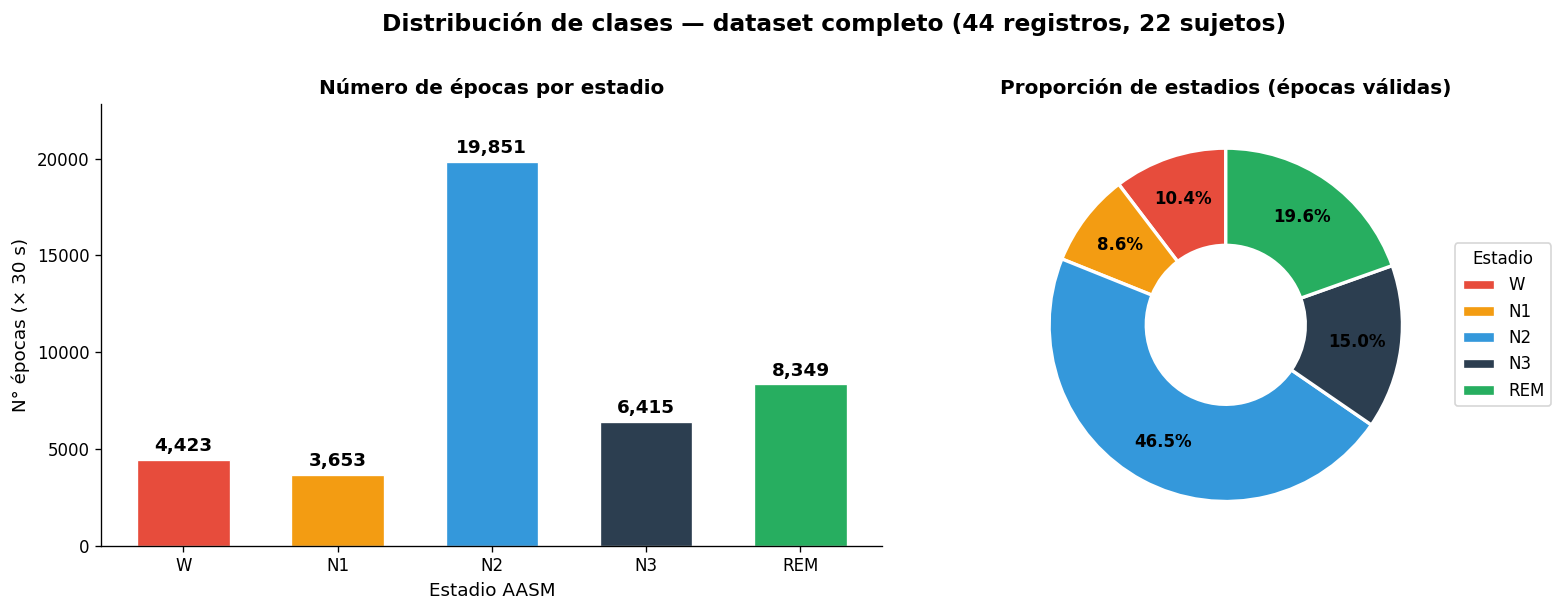

Estadio  Épocas  Horas  Global (%)  Media/reg (%)  Std/reg (%)  Mín/reg (%)  Máx/reg (%)
      W    4423   36.9        10.4           10.4          7.6          1.7         40.4
     N1    3653   30.4         8.6            8.6          4.7          2.3         20.4
     N2   19851  165.4        46.5           46.5         10.8         24.5         69.6
     N3    6415   53.5        15.0           15.0          8.3          0.0         30.1
    REM    8349   69.6        19.6           19.5          6.2          8.1         35.0

Total: 42,691 épocas válidas | 355.8 horas
Excluidas: 83 épocas de movimiento (M)

Las columnas Mín/Máx muestran cuánto varía cada estadio de un registro a otro: es la razón por la que la partición train/test debe hacerse por sujeto.


In [6]:
counts = df_valid['label'].value_counts().reindex(VALID_STAGES).fillna(0).astype(int)
props  = counts / counts.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Barras absolutas ──
bars = axes[0].bar(VALID_STAGES, [counts[s] for s in VALID_STAGES],
                   color=[STAGE_COLORS[s] for s in VALID_STAGES],
                   edgecolor='white', linewidth=0.8, width=0.6)
for bar, cnt in zip(bars, [counts[s] for s in VALID_STAGES]):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + counts.max() * 0.012,
                 f'{cnt:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_title('Número de épocas por estadio', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Estadio AASM', fontsize=11)
axes[0].set_ylabel('N° épocas (× 30 s)', fontsize=11)
axes[0].set_ylim(0, counts.max() * 1.15)

# ── Pie chart ──
wedges, texts, autotexts = axes[1].pie(
    [counts[s] for s in VALID_STAGES], labels=None,
    colors=[STAGE_COLORS[s] for s in VALID_STAGES],
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2), pctdistance=0.75)
for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight('bold')
axes[1].legend(wedges, VALID_STAGES, title='Estadio', loc='center left',
               bbox_to_anchor=(1.0, 0.5), fontsize=10)
axes[1].set_title('Proporción de estadios (épocas válidas)', fontsize=12, fontweight='bold')

plt.suptitle(f'Distribución de clases — dataset completo '
             f'({df_records.rec.nunique()} registros, {df_records.subject.nunique()} sujetos)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(IMG / 'distribucion_clases_dataset.png', bbox_inches='tight')
plt.show()

# ── Tabla resumen, con dispersión entre registros ──
per_rec_pct = (df_valid.groupby(['rec', 'label'], observed=True).size()
               .unstack(fill_value=0)
               .reindex(columns=VALID_STAGES, fill_value=0))
per_rec_pct = per_rec_pct.div(per_rec_pct.sum(axis=1), axis=0) * 100

summary = pd.DataFrame({
    'Estadio'        : VALID_STAGES,
    'Épocas'         : [counts[s] for s in VALID_STAGES],
    'Horas'          : [round(counts[s] * EPOCH_SEC / 3600, 1) for s in VALID_STAGES],
    'Global (%)'     : [round(props[s], 1) for s in VALID_STAGES],
    'Media/reg (%)'  : [round(per_rec_pct[s].mean(), 1) for s in VALID_STAGES],
    'Std/reg (%)'    : [round(per_rec_pct[s].std(), 1) for s in VALID_STAGES],
    'Mín/reg (%)'    : [round(per_rec_pct[s].min(), 1) for s in VALID_STAGES],
    'Máx/reg (%)'    : [round(per_rec_pct[s].max(), 1) for s in VALID_STAGES],
})
print(summary.to_string(index=False))
print(f'\nTotal: {counts.sum():,} épocas válidas | '
      f'{counts.sum() * EPOCH_SEC / 3600:.1f} horas')
print(f'Excluidas: {(df_epochs["label"] == "M").sum()} épocas de movimiento (M)')
print('\nLas columnas Mín/Máx muestran cuánto varía cada estadio de un registro a otro: '
      'es la razón por la que la partición train/test debe hacerse por sujeto.')

## 6. Hipnogramas — arquitectura del sueño

Un hipnograma en detalle y, debajo, los 44 en rejilla. La vista conjunta hace evidente
la heterogeneidad entre sujetos y entre noches del mismo sujeto.

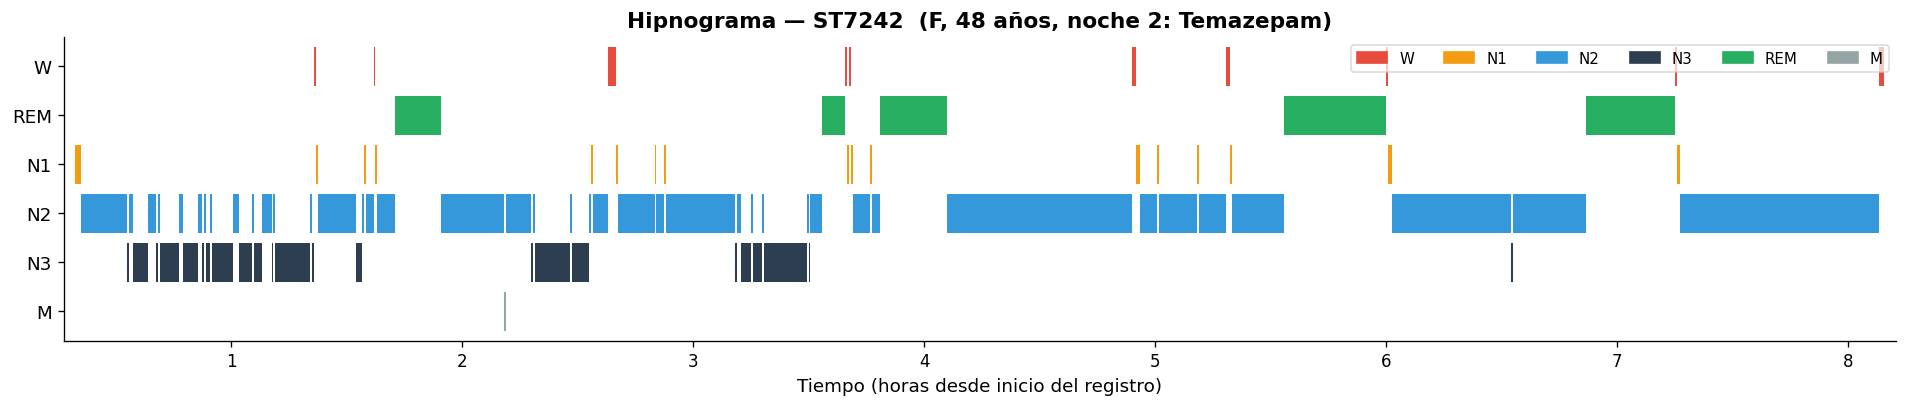

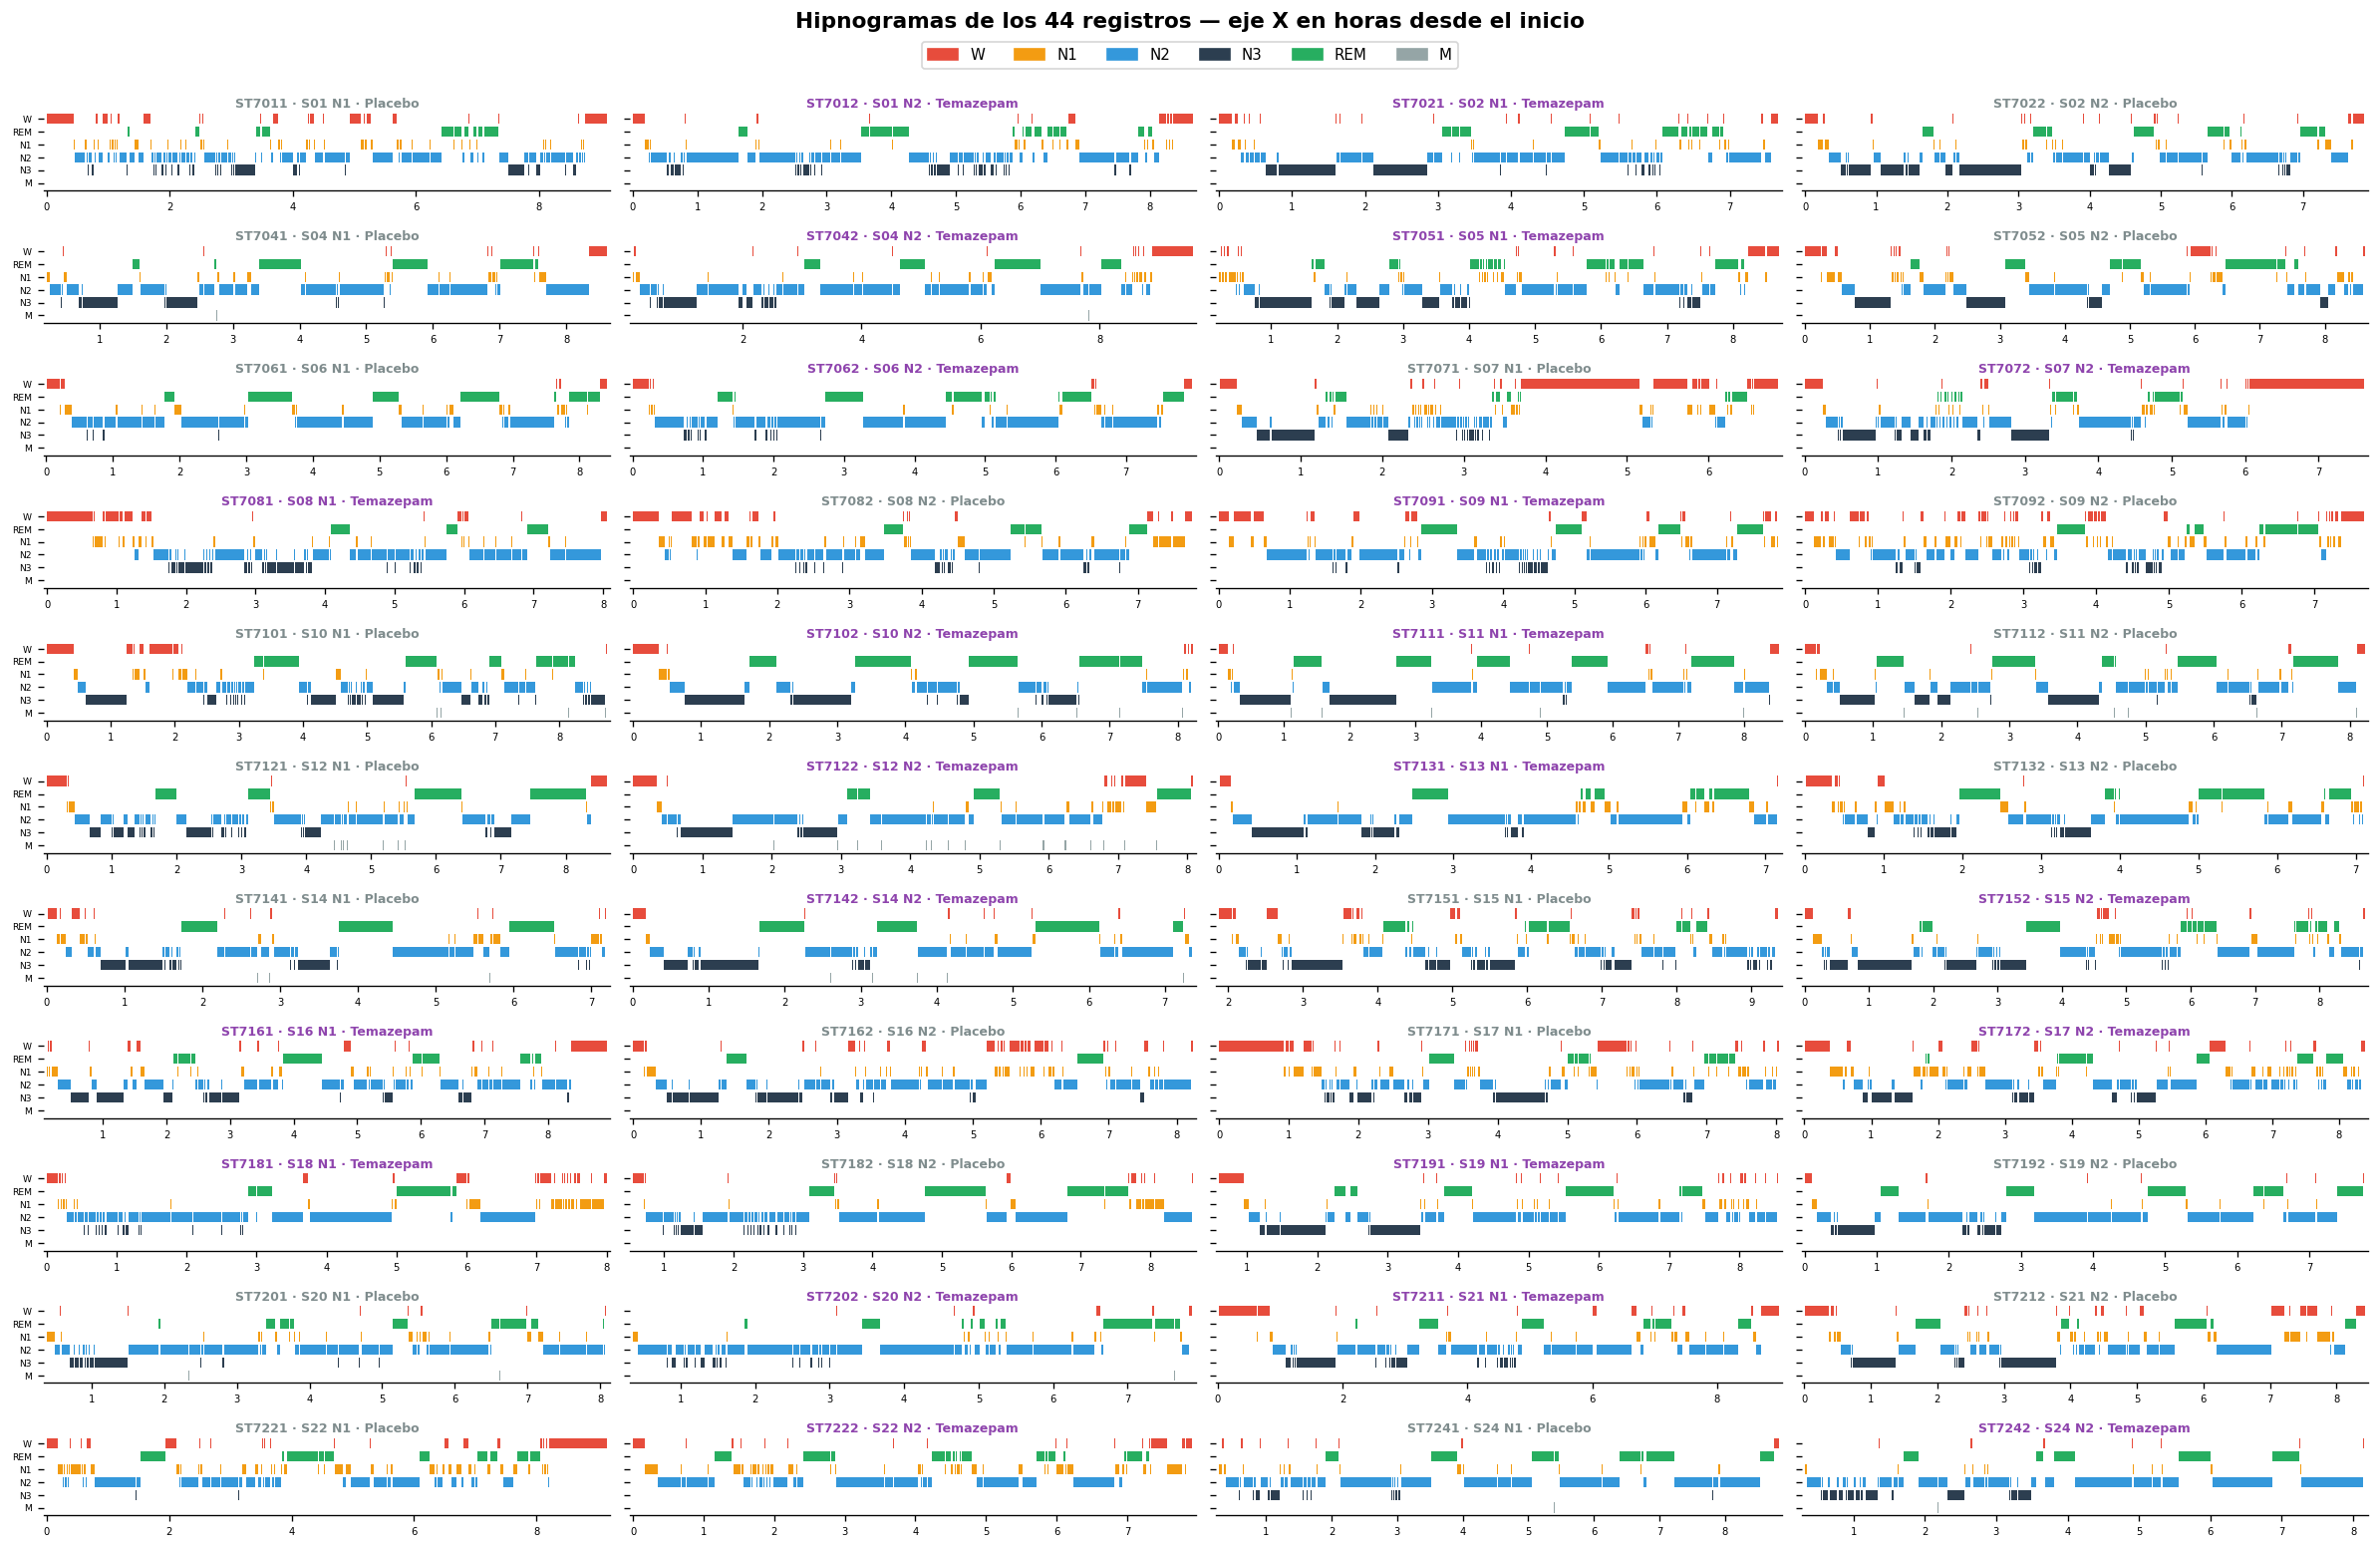

Hipnogramas guardados ✓


In [7]:
STAGE_Y = {'W': 5, 'REM': 4, 'N1': 3, 'N2': 2, 'N3': 1, 'M': 0}


def draw_hypnogram(ax, g, lw_bar=0.8):
    """Dibuja un hipnograma agrupando épocas consecutivas del mismo estadio."""
    g = g.sort_values('onset_s')
    lab = g['label'].astype(str).to_numpy()
    hrs = g['onset_s'].to_numpy() / 3600
    # Agrupar por tramos consecutivos -> broken_barh (mucho más rápido que una barra/época)
    change = np.flatnonzero(np.r_[True, lab[1:] != lab[:-1]])
    spans = {}
    for i, s in enumerate(change):
        e = change[i + 1] if i + 1 < len(change) else len(lab)
        spans.setdefault(lab[s], []).append((hrs[s], hrs[e - 1] + EPOCH_SEC / 3600 - hrs[s]))
    for stage, xr in spans.items():
        ax.broken_barh(xr, (STAGE_Y.get(stage, 0) - 0.4, 0.8),
                       facecolors=STAGE_COLORS.get(stage, '#95a5a6'), linewidth=0)
    ax.set_xlim(hrs.min() - 0.05, hrs.max() + EPOCH_SEC / 3600 + 0.05)
    ax.set_ylim(-0.6, 5.6)


# ── Un registro en detalle ──────────────────────────────────────────────────
ejemplo = 'ST7242'
g = df_epochs[df_epochs['rec'] == ejemplo]
meta = df_records[df_records.rec == ejemplo].iloc[0]

fig, ax = plt.subplots(figsize=(16, 3.5))
draw_hypnogram(ax, g)
ax.set_yticks(list(STAGE_Y.values()))              # (antes los ticks quedaban todos en y=7)
ax.set_yticklabels(list(STAGE_Y.keys()), fontsize=11)
ax.set_xlabel('Tiempo (horas desde inicio del registro)', fontsize=11)
ax.set_title(f'Hipnograma — {ejemplo}  ({meta.sex}, {meta.age} años, noche {meta.night}: '
             f'{meta.condition})', fontsize=13, fontweight='bold')
ax.legend(handles=[mpatches.Patch(color=STAGE_COLORS[s], label=s) for s in STAGE_ORDER],
          loc='upper right', ncol=6, fontsize=9, framealpha=0.7)
plt.tight_layout()
plt.savefig(IMG / 'hipnograma_ejemplo.png', bbox_inches='tight')
plt.show()

# ── Los 44 registros en rejilla ─────────────────────────────────────────────
order = df_records.sort_values(['subject', 'night'])
ncols, nrows = 4, int(np.ceil(len(order) / 4))
fig, axes = plt.subplots(nrows, ncols, figsize=(20, nrows * 1.15), sharey=True)
axes = axes.flatten()

for ax, r in zip(axes, order.itertuples()):
    draw_hypnogram(ax, df_epochs[df_epochs['rec'] == r.rec])
    ax.set_title(f'{r.rec} · S{r.subject:02d} N{r.night} · {r.condition}',
                 fontsize=7.5, color=COND_COLORS[r.condition], fontweight='bold', pad=2)
    ax.set_yticks(list(STAGE_Y.values()))
    ax.set_yticklabels(list(STAGE_Y.keys()), fontsize=5.5)
    ax.tick_params(axis='x', labelsize=6)
    ax.spines['left'].set_visible(False)
for ax in axes[len(order):]:
    ax.set_visible(False)

fig.legend(handles=[mpatches.Patch(color=STAGE_COLORS[s], label=s) for s in STAGE_ORDER],
           loc='upper center', ncol=6, fontsize=9, bbox_to_anchor=(0.5, 1.005))
plt.suptitle('Hipnogramas de los 44 registros — eje X en horas desde el inicio',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(IMG / 'hipnogramas_dataset.png', bbox_inches='tight')
plt.show()
print('Hipnogramas guardados ✓')

## 7. Señales crudas por estadio

El notebook individual elegía la época "representativa" entre las **5 primeras** de cada
estadio del único paciente. Aquí se usa un criterio con base en el dataset completo: la
época cuyo RMS (promediado entre canales) queda **más cerca de la mediana de su estadio**
sobre las ~42 800 épocas. Sólo esas 5 épocas se releen del disco.

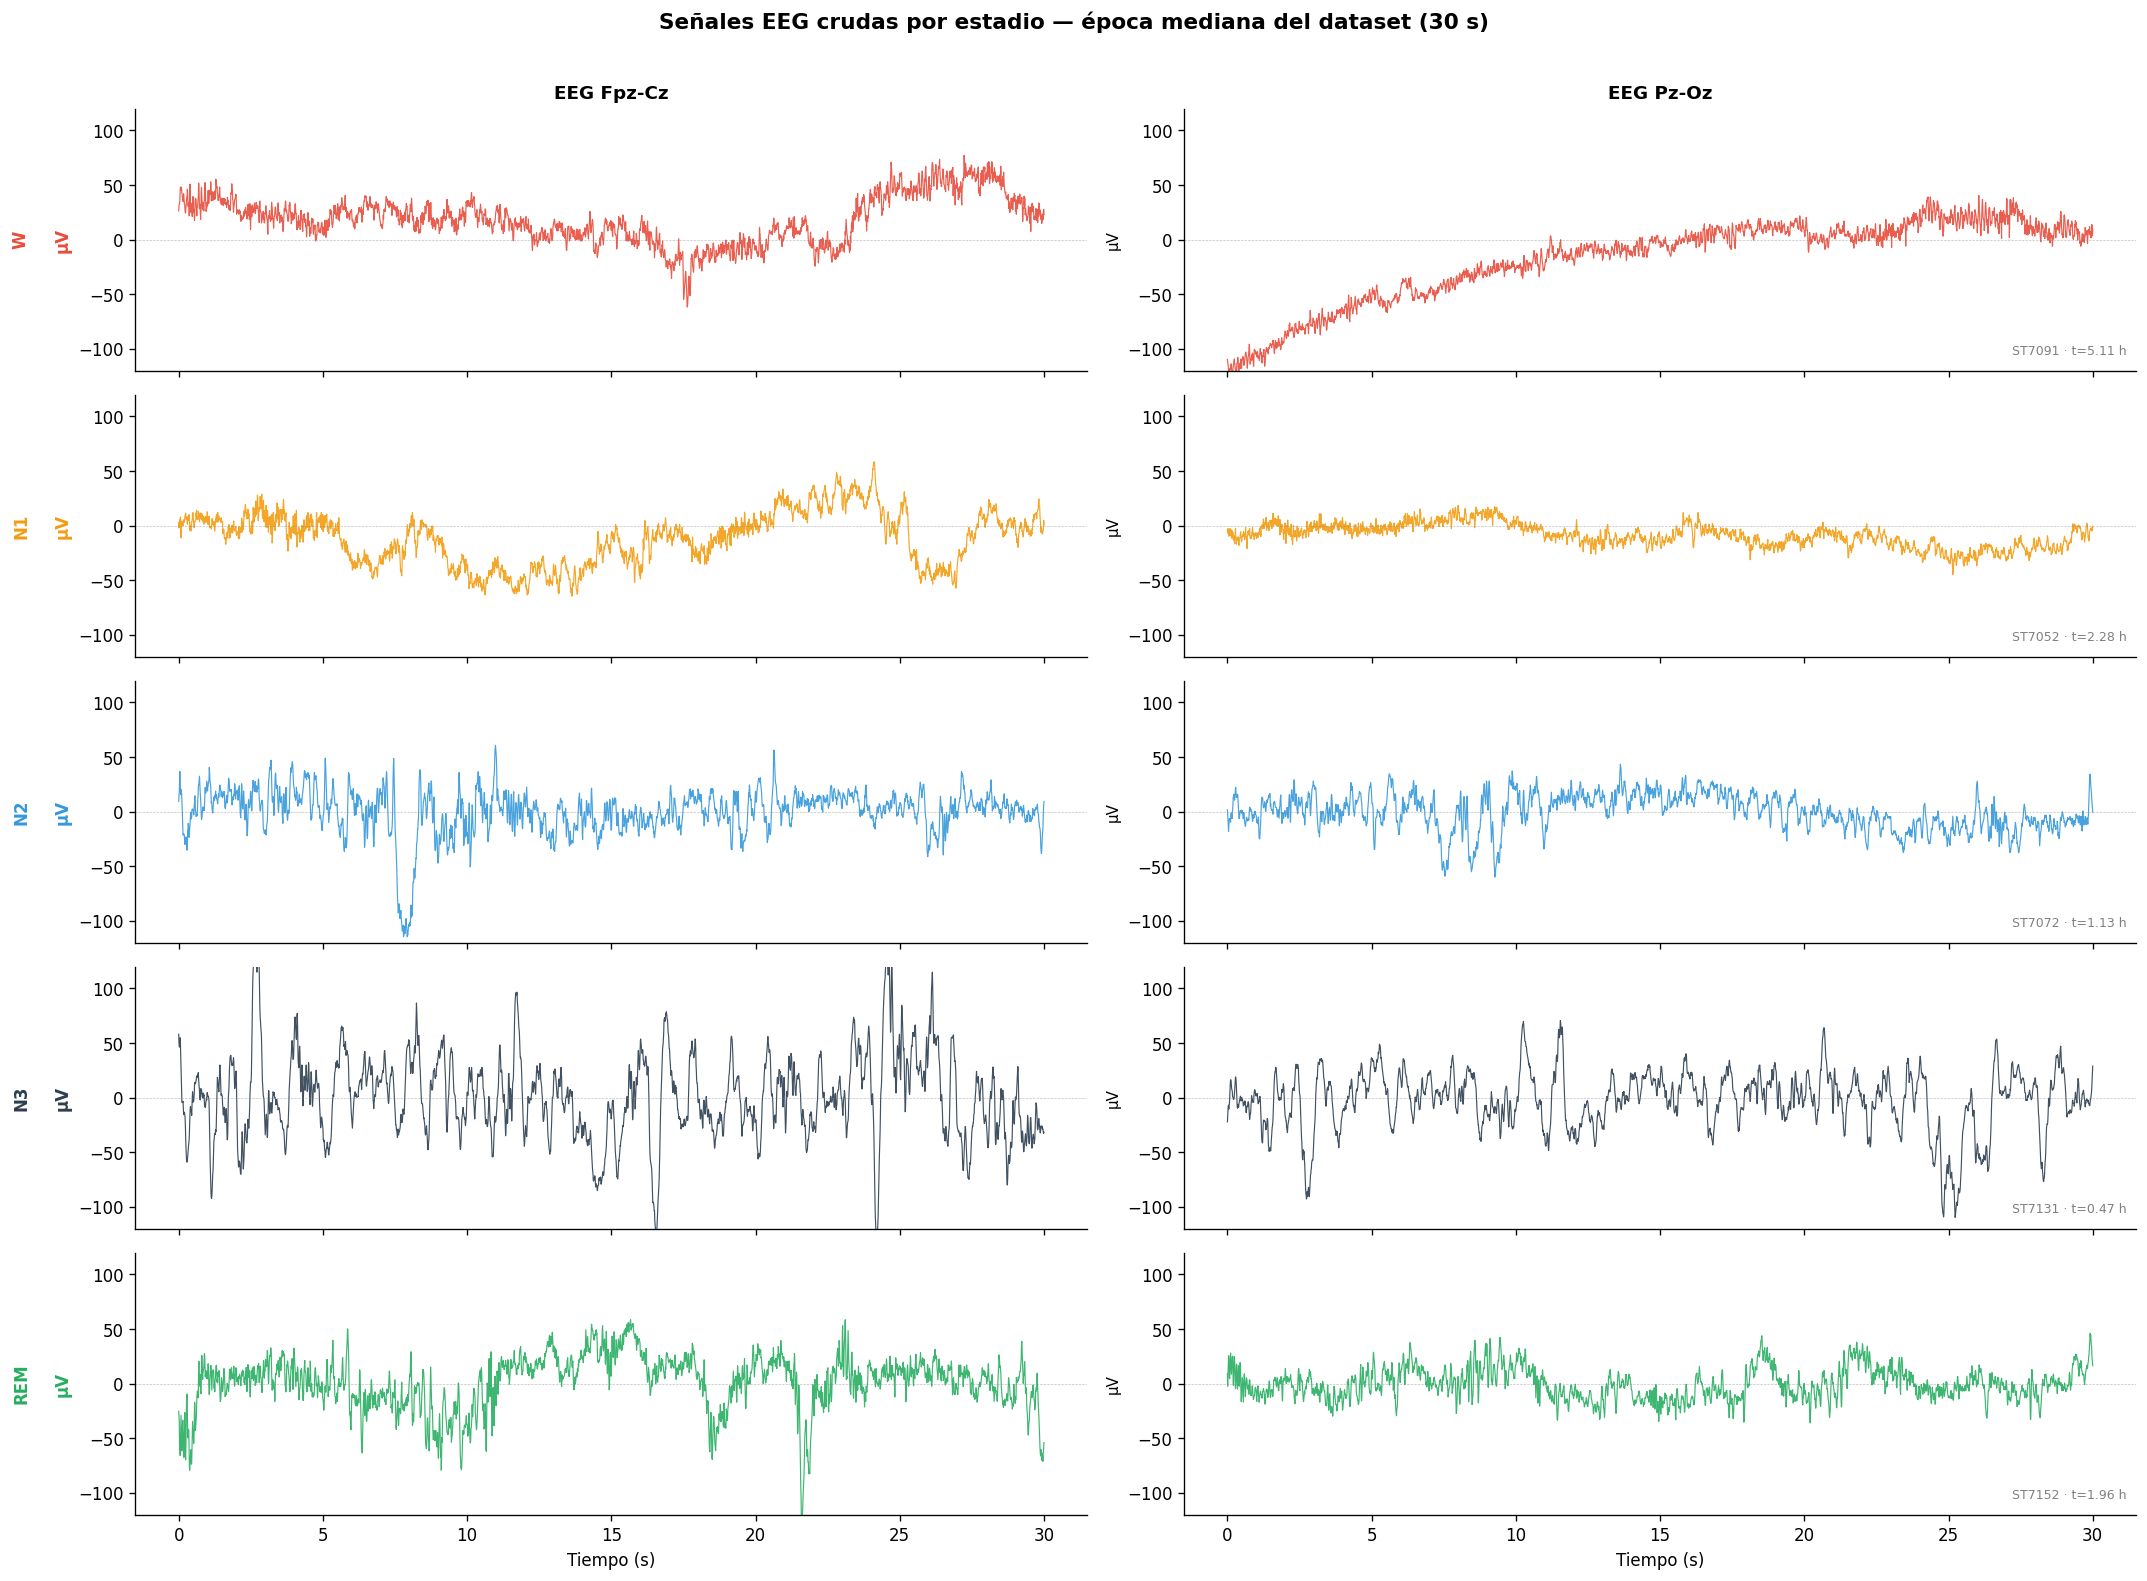

Épocas seleccionadas:
  W   → ST7091 (S09 N1, Temazepam), onset  5.11 h, RMS 34.8 µV
  N1  → ST7052 (S05 N2, Placebo), onset  2.28 h, RMS 20.4 µV
  N2  → ST7072 (S07 N2, Temazepam), onset  1.13 h, RMS 18.7 µV
  N3  → ST7131 (S13 N1, Temazepam), onset  0.47 h, RMS 32.9 µV
  REM → ST7152 (S15 N2, Temazepam), onset  1.96 h, RMS 19.4 µV


In [8]:
df_valid['rms_mean'] = df_valid[['fpz_rms', 'pz_rms']].mean(axis=1)

picks = {}
for stage in VALID_STAGES:
    sub = df_valid[df_valid['label'] == stage]
    target = sub['rms_mean'].median()
    row = sub.iloc[(sub['rms_mean'] - target).abs().argmin()]
    picks[stage] = row

# Releer del disco solo las épocas seleccionadas
raw_cache = {}
epoch_data = {}
for stage, row in picks.items():
    if row['rec'] not in raw_cache:
        path = df_records.loc[df_records.rec == row['rec'], 'psg_path'].iloc[0]
        raw_cache[row['rec']] = (mne.io.read_raw_edf(path, preload=True, verbose=False)
                                 .pick(CHANNELS))
    raw = raw_cache[row['rec']]
    start = int(round(row['onset_s'] * SFREQ))
    epoch_data[stage] = raw.get_data(start=start, stop=start + EPOCH_LEN) * 1e6
del raw_cache

t = np.linspace(0, EPOCH_SEC, EPOCH_LEN)
fig, axes = plt.subplots(len(VALID_STAGES), 2,
                         figsize=(18, len(VALID_STAGES) * 2.6), sharex=True)

for i, stage in enumerate(VALID_STAGES):
    data = epoch_data[stage]
    row = picks[stage]
    for j, ch_name in enumerate(CHANNELS):
        ax = axes[i][j]
        ax.plot(t, data[j], color=STAGE_COLORS[stage], linewidth=0.7, alpha=0.9)
        ax.axhline(0, color='gray', linewidth=0.4, linestyle='--', alpha=0.5)
        ax.set_ylim(-120, 120)
        ax.set_ylabel('µV', fontsize=9)
        if i == 0:
            ax.set_title(ch_name, fontsize=11, fontweight='bold')
        if i == len(VALID_STAGES) - 1:
            ax.set_xlabel('Tiempo (s)', fontsize=10)
        if j == 0:
            ax.set_ylabel(f'{stage}\n\nµV', fontsize=10, fontweight='bold',
                          color=STAGE_COLORS[stage])
        if j == 1:
            ax.text(0.99, 0.05, f"{row['rec']} · t={row['onset_s'] / 3600:.2f} h",
                    transform=ax.transAxes, ha='right', va='bottom',
                    fontsize=7.5, color='gray')

plt.suptitle('Señales EEG crudas por estadio — época mediana del dataset (30 s)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(IMG / 'senales_crudas_por_estadio.png', bbox_inches='tight')
plt.show()

print('Épocas seleccionadas:')
for stage, row in picks.items():
    print(f"  {stage:3s} → {row['rec']} (S{int(row['subject']):02d} N{int(row['night'])}, "
          f"{row['condition']}), onset {row['onset_s'] / 3600:5.2f} h, "
          f"RMS {row['rms_mean']:.1f} µV")

## 8. Análisis espectral (PSD) por estadio

La curva es la media de las PSD por registro (cada registro pesa igual, para que los más
largos no dominen). La banda sombreada ya no es la dispersión entre épocas de un paciente
sino la **dispersión entre los 44 registros**, que es la que importa a la hora de anticipar
cómo generalizará un modelo a un sujeto nuevo.

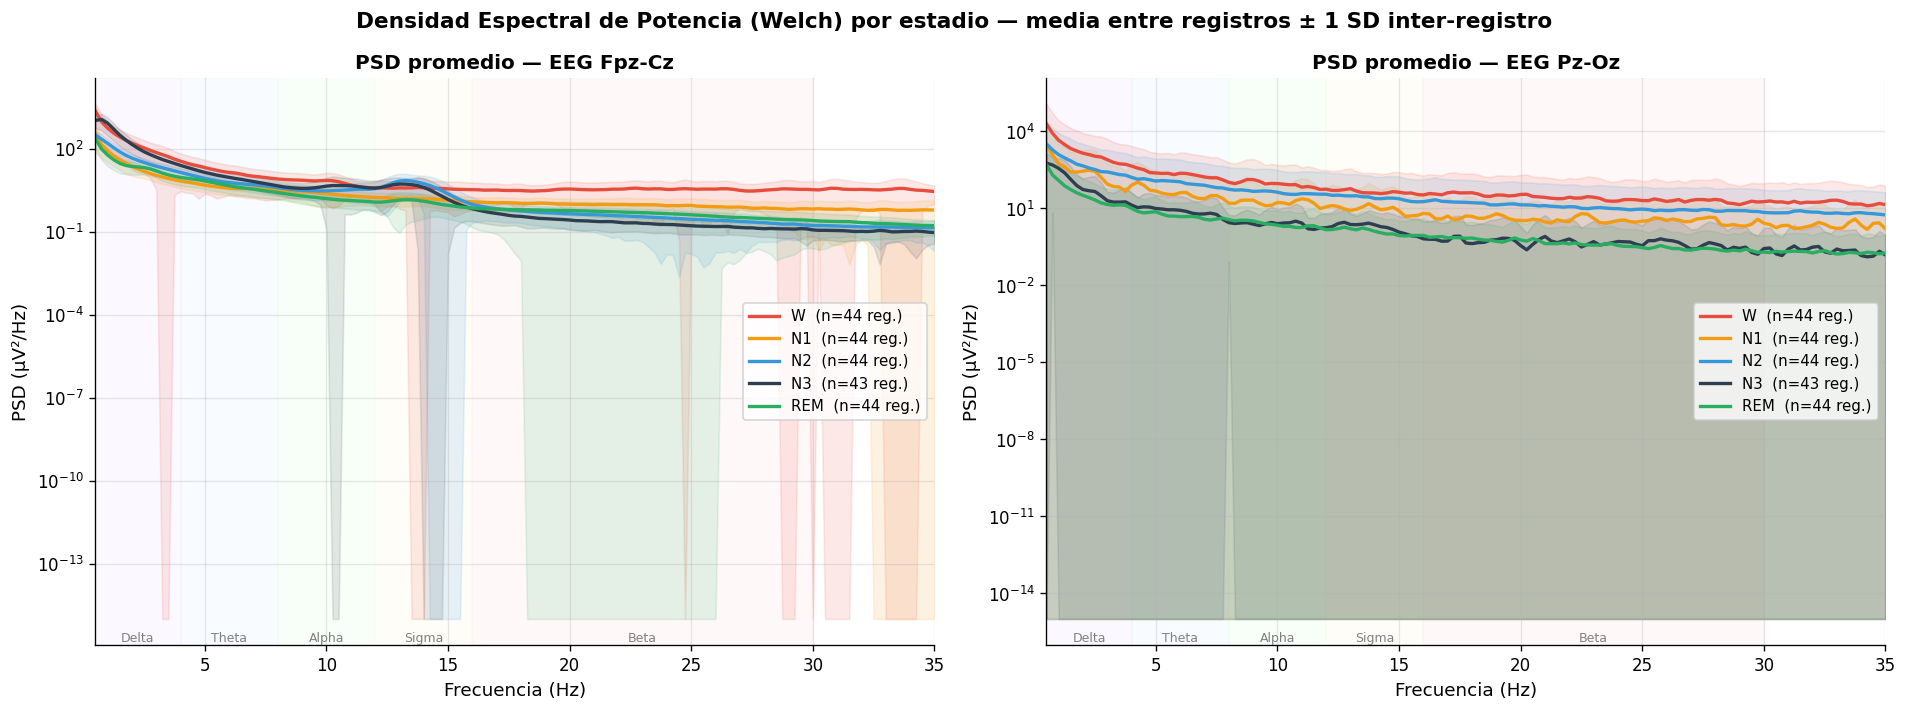

PSD guardado ✓


In [9]:
freqs = np.sort(df_psd['freq'].unique())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for j, ch in enumerate(CHANNELS):
    ax = axes[j]
    for stage in VALID_STAGES:
        sub = df_psd[(df_psd.channel == ch) & (df_psd.label == stage)]
        if sub.empty:
            continue
        wide = sub.pivot(index='rec', columns='freq', values='psd')  # (n_registros, n_freqs)
        mean_psd, std_psd = wide.mean(axis=0).to_numpy(), wide.std(axis=0).to_numpy()
        ax.semilogy(freqs, mean_psd, label=f'{stage}  (n={len(wide)} reg.)',
                    color=STAGE_COLORS[stage], linewidth=2)
        ax.fill_between(freqs, np.maximum(mean_psd - std_psd, 1e-15), mean_psd + std_psd,
                        color=STAGE_COLORS[stage], alpha=0.12)

    band_colors = ['#f0e6ff', '#e6f3ff', '#e6ffe6', '#fff9e6', '#ffe6e6']
    for (band, (f1, f2)), bc in zip(BANDS.items(), band_colors):
        ax.axvspan(f1, f2, alpha=0.25, color=bc, zorder=0)
        ax.text((f1 + f2) / 2, ax.get_ylim()[0], band, ha='center', va='bottom',
                fontsize=7.5, color='gray')

    ax.set_xlabel('Frecuencia (Hz)', fontsize=11)
    ax.set_ylabel('PSD (µV²/Hz)', fontsize=11)
    ax.set_title(f'PSD promedio — {ch}', fontsize=12, fontweight='bold')
    ax.set_xlim(PSD_FMIN, PSD_FMAX)
    ax.legend(fontsize=9, framealpha=0.8)
    ax.grid(True, alpha=0.3, which='both')

plt.suptitle('Densidad Espectral de Potencia (Welch) por estadio — media entre registros '
             '± 1 SD inter-registro', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(IMG / 'PSD_por_estadio.png', bbox_inches='tight')
plt.show()
print('PSD guardado ✓')

## 9. Potencia de banda por estadio (heatmap)

Potencia relativa media calculada sobre **todas** las épocas válidas del dataset.

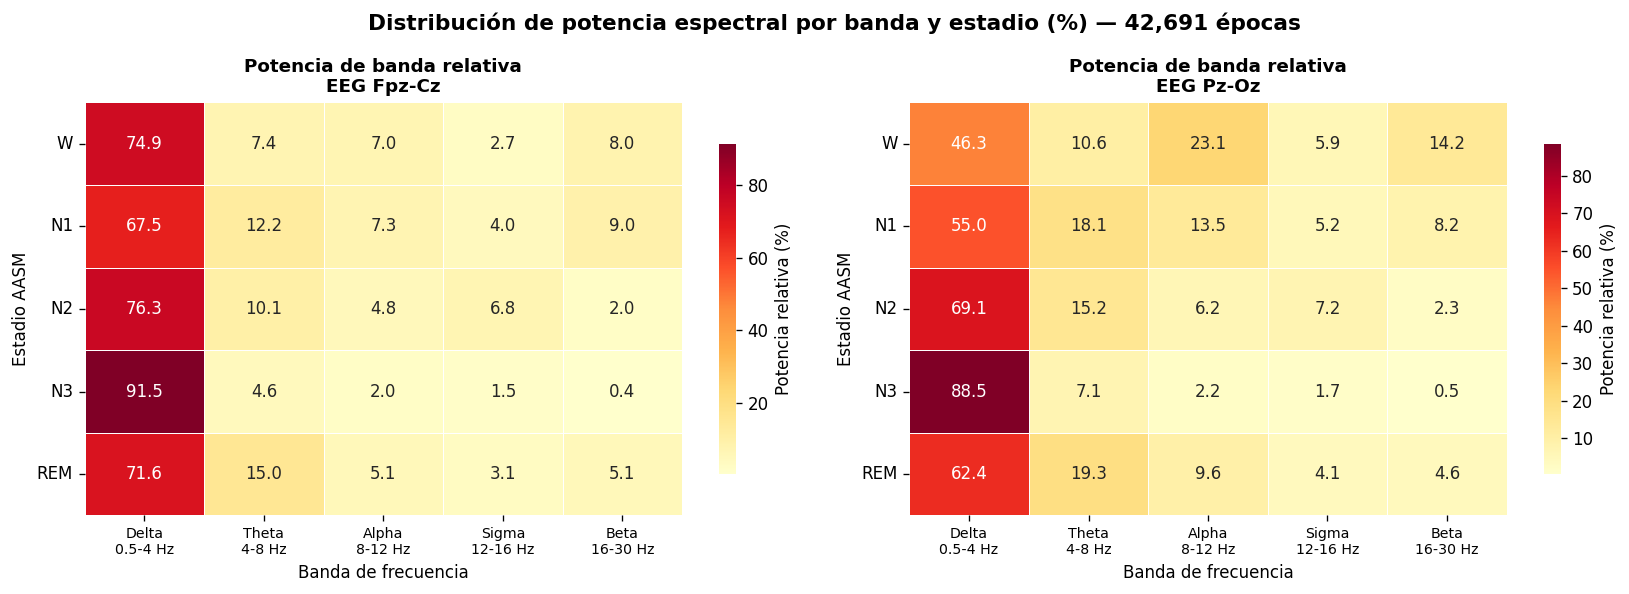

Heatmap guardado ✓


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for j, ch in enumerate(CHANNELS):
    s = CH_SHORT[ch]
    cols = [f'{s}_rel_{b.lower()}' for b in BANDS]
    mat = (df_valid.groupby('label', observed=True)[cols].mean()
           .reindex(VALID_STAGES))
    mat.columns = [BAND_LABELS[b] for b in BANDS]

    sns.heatmap(mat, ax=axes[j], annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5,
                cbar_kws={'label': 'Potencia relativa (%)', 'shrink': 0.8},
                annot_kws={'size': 10})
    axes[j].set_title(f'Potencia de banda relativa\n{ch}', fontsize=11, fontweight='bold')
    axes[j].set_ylabel('Estadio AASM', fontsize=10)
    axes[j].set_xlabel('Banda de frecuencia', fontsize=10)
    axes[j].tick_params(axis='x', labelsize=8.5)
    axes[j].tick_params(axis='y', rotation=0)

plt.suptitle(f'Distribución de potencia espectral por banda y estadio (%) — '
             f'{len(df_valid):,} épocas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(IMG / 'heatmap_bandas_estadio.png', bbox_inches='tight')
plt.show()
print('Heatmap guardado ✓')

## 10. Estadísticas descriptivas de señales crudas por estadio

Sobre las ~42 800 épocas, no sobre 20 por estadio de un solo paciente.

In [11]:
STAT_LABELS = {'mean': 'Media (µV)', 'std': 'Std (µV)', 'ptp': 'Rango pico-pico',
               'kurt': 'Kurtosis', 'skew': 'Skewness', 'rms': 'RMS (µV)'}

rows = []
for ch in CHANNELS:
    s = CH_SHORT[ch]
    g = df_valid.groupby('label', observed=True)[[f'{s}_{k}' for k in STAT_LABELS]].mean()
    g.columns = list(STAT_LABELS.values())
    g['Canal'] = ch
    g['N épocas'] = df_valid.groupby('label', observed=True).size()
    rows.append(g.reindex(VALID_STAGES))

df_summary = (pd.concat(rows).reset_index()
              .rename(columns={'label': 'Estadio'})
              .set_index(['Estadio', 'Canal'])
              .sort_index())
df_summary = df_summary[['N épocas'] + list(STAT_LABELS.values())].round(3)

print('=== Estadísticas descriptivas promedio por estadio y canal ===')
print(f'    (sobre {len(df_valid):,} épocas de {df_records.rec.nunique()} registros)\n')
print(df_summary.to_string())

=== Estadísticas descriptivas promedio por estadio y canal ===
    (sobre 42,691 épocas de 44 registros)

                    N épocas  Media (µV)  Std (µV)  Rango pico-pico  Kurtosis  Skewness  RMS (µV)
Estadio Canal                                                                                    
N1      EEG Fpz-Cz      3653       0.837    32.143          194.477     1.202    -0.326    34.904
        EEG Pz-Oz       3653      -2.189    33.497          170.905     2.129     0.169    40.251
N2      EEG Fpz-Cz     19851      -0.051    25.728          192.190     2.382    -0.403    26.683
        EEG Pz-Oz      19851       0.430    19.528          132.779     2.479    -0.276    20.924
N3      EEG Fpz-Cz      6415       0.132    42.693          289.492     1.084    -0.115    43.274
        EEG Pz-Oz       6415       0.516    26.533          178.045     1.361    -0.335    26.824
REM     EEG Fpz-Cz      8349       0.086    29.807          176.325     0.670    -0.138    31.916
        EEG 

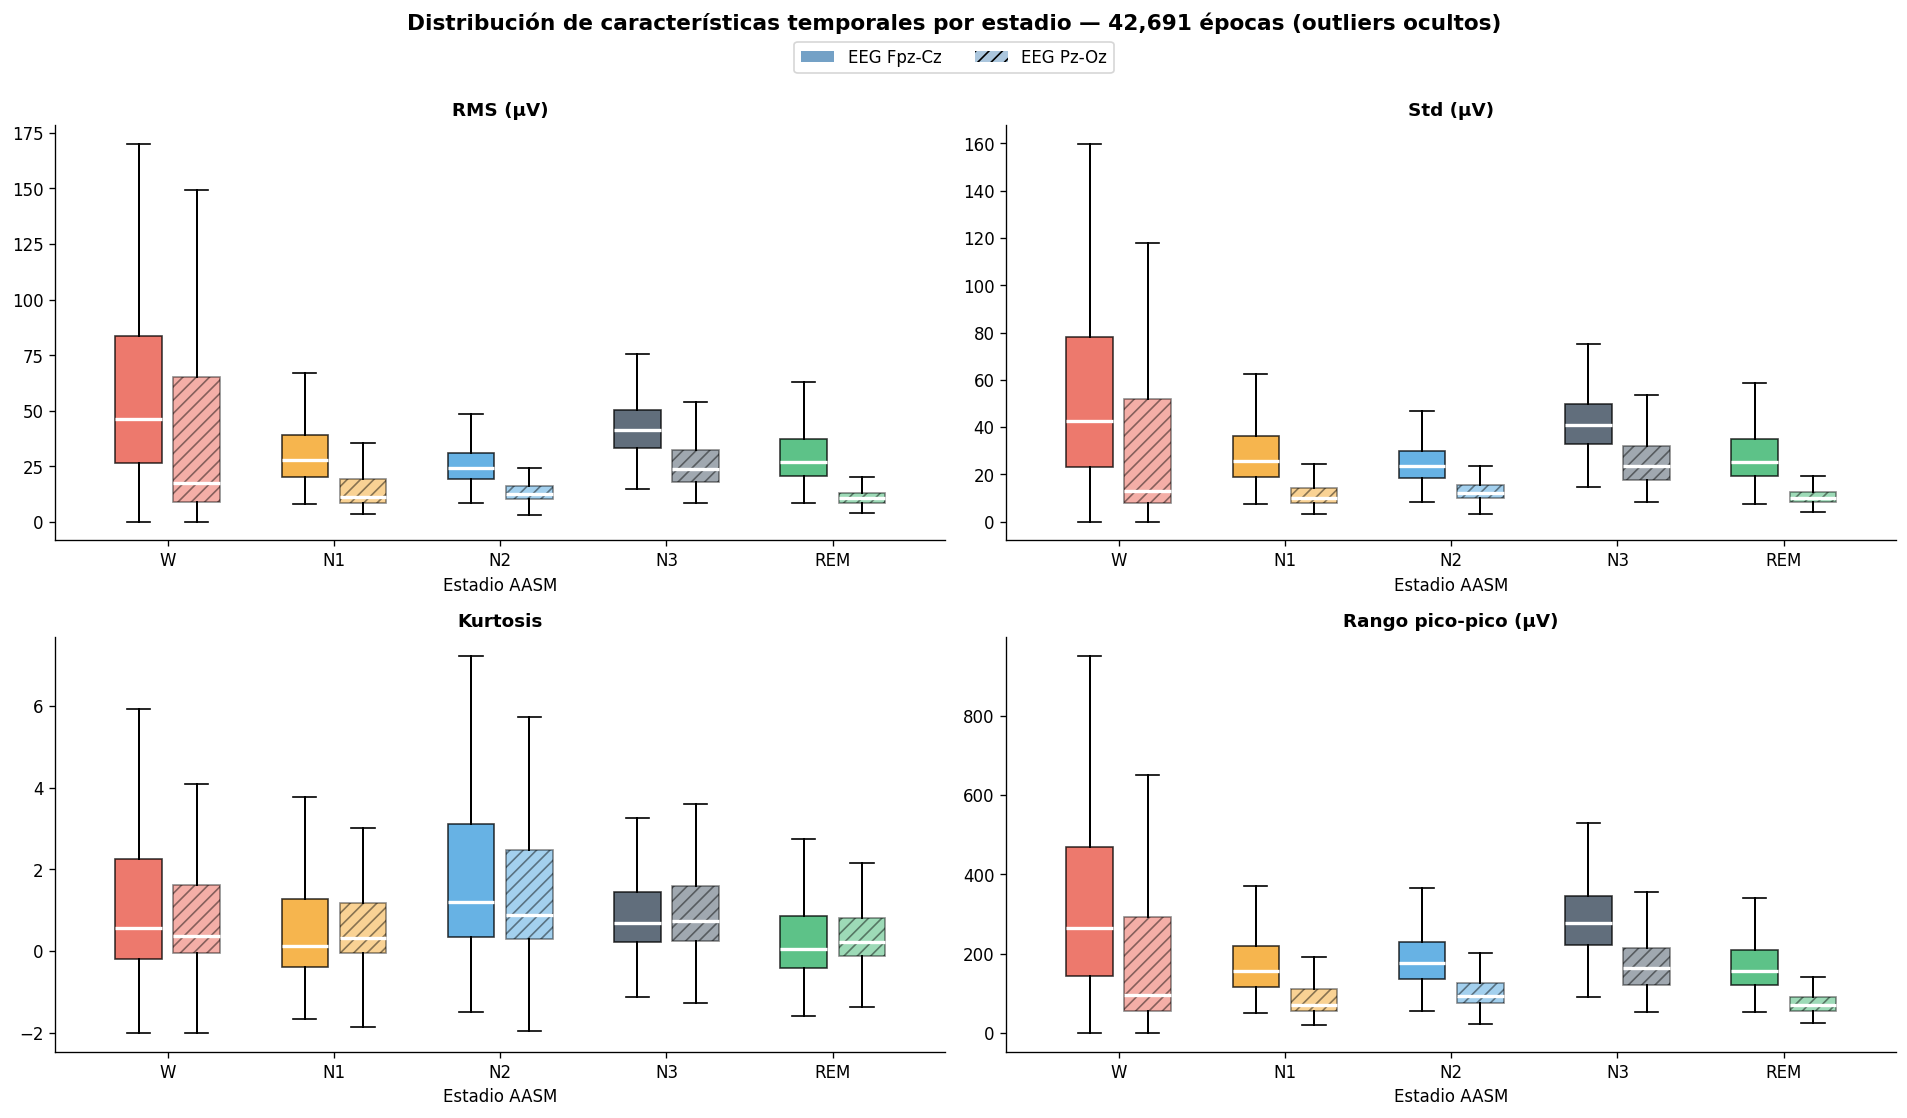

Boxplots guardados ✓


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 9))
metrics = [('rms', 'RMS (µV)'), ('std', 'Std (µV)'),
           ('kurt', 'Kurtosis'), ('ptp', 'Rango pico-pico (µV)')]

for ax, (key, title) in zip(axes.flatten(), metrics):
    for j, ch in enumerate(CHANNELS):
        col = f'{CH_SHORT[ch]}_{key}'
        stage_vals = [df_valid.loc[df_valid['label'] == s, col].to_numpy()
                      for s in VALID_STAGES]
        positions = np.arange(len(VALID_STAGES)) + j * 0.35
        bp = ax.boxplot(stage_vals, positions=positions, widths=0.28,
                        patch_artist=True, notch=False, showfliers=False,
                        medianprops=dict(color='white', linewidth=2),
                        whiskerprops=dict(linewidth=1.2))
        for patch, stage in zip(bp['boxes'], VALID_STAGES):
            patch.set_facecolor(STAGE_COLORS[stage])
            patch.set_alpha(0.75 if j == 0 else 0.45)
            if j == 1:
                patch.set_hatch('///')

    ax.set_xticks(np.arange(len(VALID_STAGES)) + 0.175)
    ax.set_xticklabels(VALID_STAGES, fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Estadio AASM', fontsize=10)

fig.legend(handles=[
    mpatches.Patch(facecolor='steelblue', alpha=0.75, label=CHANNELS[0]),
    mpatches.Patch(facecolor='steelblue', alpha=0.45, hatch='///', label=CHANNELS[1]),
], loc='upper center', ncol=2, fontsize=10, bbox_to_anchor=(0.5, 1.01))

plt.suptitle(f'Distribución de características temporales por estadio — '
             f'{len(df_valid):,} épocas (outliers ocultos)',
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig(IMG / 'boxplots_estadisticas.png', bbox_inches='tight')
plt.show()
print('Boxplots guardados ✓')

## 11. Análisis de desbalance de clases

Con el dataset completo, la comparación contra las cifras publicadas para Sleep-EDF-20
pasa a ser una comparación legítima entre datasets, y no entre un paciente y un dataset.

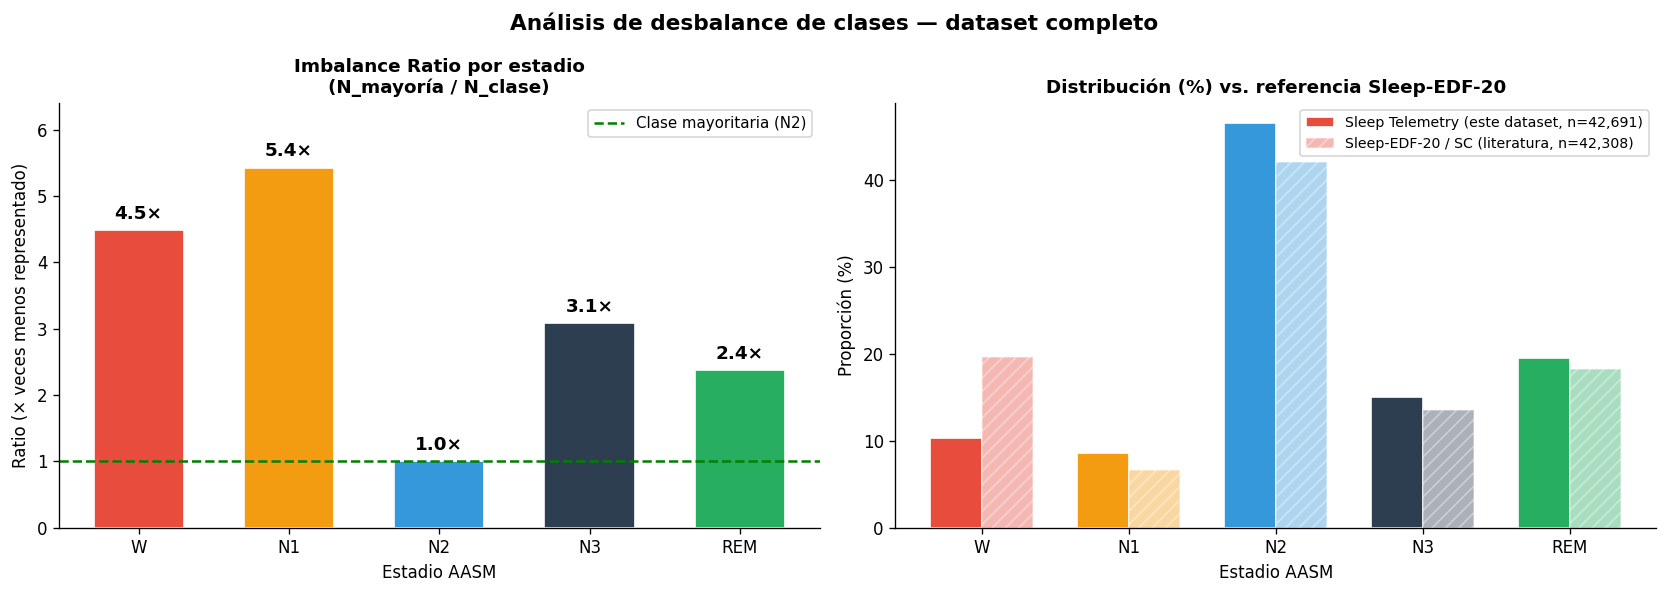

=== Imbalance Ratio (IR) — clase mayoritaria: N2 ===
  W  :   4.5× menos épocas que N2   (4,423 épocas, 10.4%)
  N1 :   5.4× menos épocas que N2   (3,653 épocas, 8.6%)
  N2 :   1.0× menos épocas que N2   (19,851 épocas, 46.5%)
  N3 :   3.1× menos épocas que N2   (6,415 épocas, 15.0%)
  REM:   2.4× menos épocas que N2   (8,349 épocas, 19.6%)

IR intra-registro: mediana 8.7×, rango 2.3× - 219.0×
El desbalance es estructural del dominio, no un artefacto de agregar registros.


In [13]:
counts_valid = df_valid['label'].value_counts().reindex(VALID_STAGES).fillna(0)
majority = counts_valid.idxmax()
ir = (counts_valid.max() / counts_valid).round(2)      # Imbalance Ratio

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Imbalance Ratio ──
bars = axes[0].bar(ir.index, ir.values, color=[STAGE_COLORS[s] for s in ir.index],
                   edgecolor='white', width=0.6)
for bar, val in zip(bars, ir.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + ir.max() * 0.02,
                 f'{val:.1f}×', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].axhline(1, color='green', linestyle='--', linewidth=1.5,
                label=f'Clase mayoritaria ({majority})')
axes[0].set_title('Imbalance Ratio por estadio\n(N_mayoría / N_clase)',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('Estadio AASM', fontsize=10)
axes[0].set_ylabel('Ratio (× veces menos representado)', fontsize=10)
axes[0].set_ylim(0, ir.max() * 1.18)
axes[0].legend(fontsize=9)

# ── Comparativa con Sleep-EDF-20 (referencia de literatura) ──
# Valores reportados en Supratak et al. 2017 para el subset SC-20
ref_counts = {'W': 8285, 'N1': 2804, 'N2': 17799, 'N3': 5703, 'REM': 7717}
ref_total = sum(ref_counts.values())
ref_pct = {k: v / ref_total * 100 for k, v in ref_counts.items()}
our_pct = (counts_valid / counts_valid.sum() * 100).to_dict()

x, w = np.arange(len(VALID_STAGES)), 0.35
axes[1].bar(x - w / 2, [our_pct.get(s, 0) for s in VALID_STAGES], width=w,
            label=f'Sleep Telemetry (este dataset, n={len(df_valid):,})',
            color=[STAGE_COLORS[s] for s in VALID_STAGES], edgecolor='white')
axes[1].bar(x + w / 2, [ref_pct.get(s, 0) for s in VALID_STAGES], width=w,
            label=f'Sleep-EDF-20 / SC (literatura, n={ref_total:,})',
            color=[STAGE_COLORS[s] for s in VALID_STAGES], edgecolor='white',
            alpha=0.4, hatch='///')
axes[1].set_xticks(x)
axes[1].set_xticklabels(VALID_STAGES, fontsize=10)
axes[1].set_title('Distribución (%) vs. referencia Sleep-EDF-20', fontsize=11,
                  fontweight='bold')
axes[1].set_xlabel('Estadio AASM', fontsize=10)
axes[1].set_ylabel('Proporción (%)', fontsize=10)
axes[1].legend(fontsize=8.5)

plt.suptitle('Análisis de desbalance de clases — dataset completo',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(IMG / 'desbalance_clases.png', bbox_inches='tight')
plt.show()

print(f'=== Imbalance Ratio (IR) — clase mayoritaria: {majority} ===')
for s in ir.index:
    print(f'  {s:3s}: {ir[s]:5.1f}× menos épocas que {majority}   '
          f'({int(counts_valid[s]):,} épocas, {our_pct[s]:.1f}%)')

# ¿Está el desbalance presente en todos los registros o solo en algunos?
ir_per_rec = per_rec_pct.max(axis=1) / per_rec_pct.replace(0, np.nan).min(axis=1)
print(f'\nIR intra-registro: mediana {ir_per_rec.median():.1f}×, '
      f'rango {ir_per_rec.min():.1f}× - {ir_per_rec.max():.1f}×')
print('El desbalance es estructural del dominio, no un artefacto de agregar registros.')

## 12. Efecto del temazepam sobre la arquitectura del sueño

Cada sujeto durmió una noche con placebo y otra con temazepam, así que el diseño es
**pareado intra-sujeto**: cada sujeto es su propio control y la comparación se hace sobre
las 22 diferencias, no sobre 44 muestras independientes. El contraste se evalúa con el
test de Wilcoxon de rangos con signo (no paramétrico, apropiado para n=22).

El temazepam es una benzodiacepina, y la farmacología predice dos efectos concretos:
**más actividad sigma/beta** (las benzodiacepinas inducen husos de sueño rápidos) y
**menos sueño profundo N3**. Que esos efectos aparezcan o no en los datos sirve además
como validación de todo el pipeline de extracción.

In [14]:
def sleep_architecture(g):
    """Métricas clásicas de arquitectura del sueño para un registro."""
    g = g.sort_values('onset_s')
    lab = g['label'].astype(str).to_numpy()
    n = len(lab)
    is_sleep = np.isin(lab, SLEEP_STAGES)

    trt = n * EPOCH_SEC / 60                             # tiempo de registro anotado (min)
    tst = int(is_sleep.sum()) * EPOCH_SEC / 60           # tiempo total de sueño (min)

    out = {'TST (min)': tst, 'Eficiencia (%)': tst / trt * 100 if trt else np.nan}

    if is_sleep.any():
        first, last = int(np.argmax(is_sleep)), int(len(lab) - 1 - np.argmax(is_sleep[::-1]))
        out['Latencia sueño (min)'] = first * EPOCH_SEC / 60
        out['WASO (min)'] = int((lab[first:last + 1] == 'W').sum()) * EPOCH_SEC / 60
        rem = np.flatnonzero(lab == 'REM')
        out['Latencia REM (min)'] = ((rem[0] - first) * EPOCH_SEC / 60
                                     if len(rem) and rem[0] >= first else np.nan)
    else:
        out.update({'Latencia sueño (min)': np.nan, 'WASO (min)': np.nan,
                    'Latencia REM (min)': np.nan})

    for s in SLEEP_STAGES:
        out[f'% {s}'] = (lab == s).sum() / is_sleep.sum() * 100 if is_sleep.any() else np.nan
    return pd.Series(out)


arch = (df_valid.groupby('rec', observed=True).apply(sleep_architecture, include_groups=False)
        .reset_index()
        .merge(df_records[['rec', 'subject', 'night', 'condition', 'age', 'sex']], on='rec'))

METRICS = ['TST (min)', 'Eficiencia (%)', 'WASO (min)', 'Latencia sueño (min)',
           'Latencia REM (min)', '% N1', '% N2', '% N3', '% REM']

# ── Test de Wilcoxon pareado por sujeto ─────────────────────────────────────
res = []
paired = {}
for m in METRICS:
    piv = arch.pivot(index='subject', columns='condition', values=m).dropna()
    paired[m] = piv
    stat, p = wilcoxon(piv['Placebo'], piv['Temazepam'])
    res.append({
        'Métrica': m, 'n pares': len(piv),
        'Placebo': piv['Placebo'].mean(), 'Temazepam': piv['Temazepam'].mean(),
        'Δ (T-P)': piv['Temazepam'].mean() - piv['Placebo'].mean(),
        'p (Wilcoxon)': p,
        'sig.': '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.',
    })

df_test = pd.DataFrame(res)
print('=== Arquitectura del sueño: placebo vs. temazepam (22 pares intra-sujeto) ===\n')
print(df_test.round({'Placebo': 1, 'Temazepam': 1, 'Δ (T-P)': 1, 'p (Wilcoxon)': 4})
      .to_string(index=False))
print('\n*** p<0.001   ** p<0.01   * p<0.05   n.s. no significativo')

=== Arquitectura del sueño: placebo vs. temazepam (22 pares intra-sujeto) ===

             Métrica  n pares  Placebo  Temazepam  Δ (T-P)  p (Wilcoxon) sig.
           TST (min)       22    427.6      442.2     14.6        0.1440 n.s.
      Eficiencia (%)       22     88.4       90.8      2.4        0.0587 n.s.
          WASO (min)       22     34.0       21.3    -12.7        0.0148    *
Latencia sueño (min)       22     13.8       12.4     -1.4        0.5858 n.s.
  Latencia REM (min)       22    100.7      111.0     10.2        0.3464 n.s.
                % N1       22     11.3        8.4     -3.0        0.0172    *
                % N2       22     50.0       53.4      3.4        0.0229    *
                % N3       22     17.1       16.8     -0.3        0.4434 n.s.
               % REM       22     21.6       21.5     -0.1        1.0000 n.s.

*** p<0.001   ** p<0.01   * p<0.05   n.s. no significativo


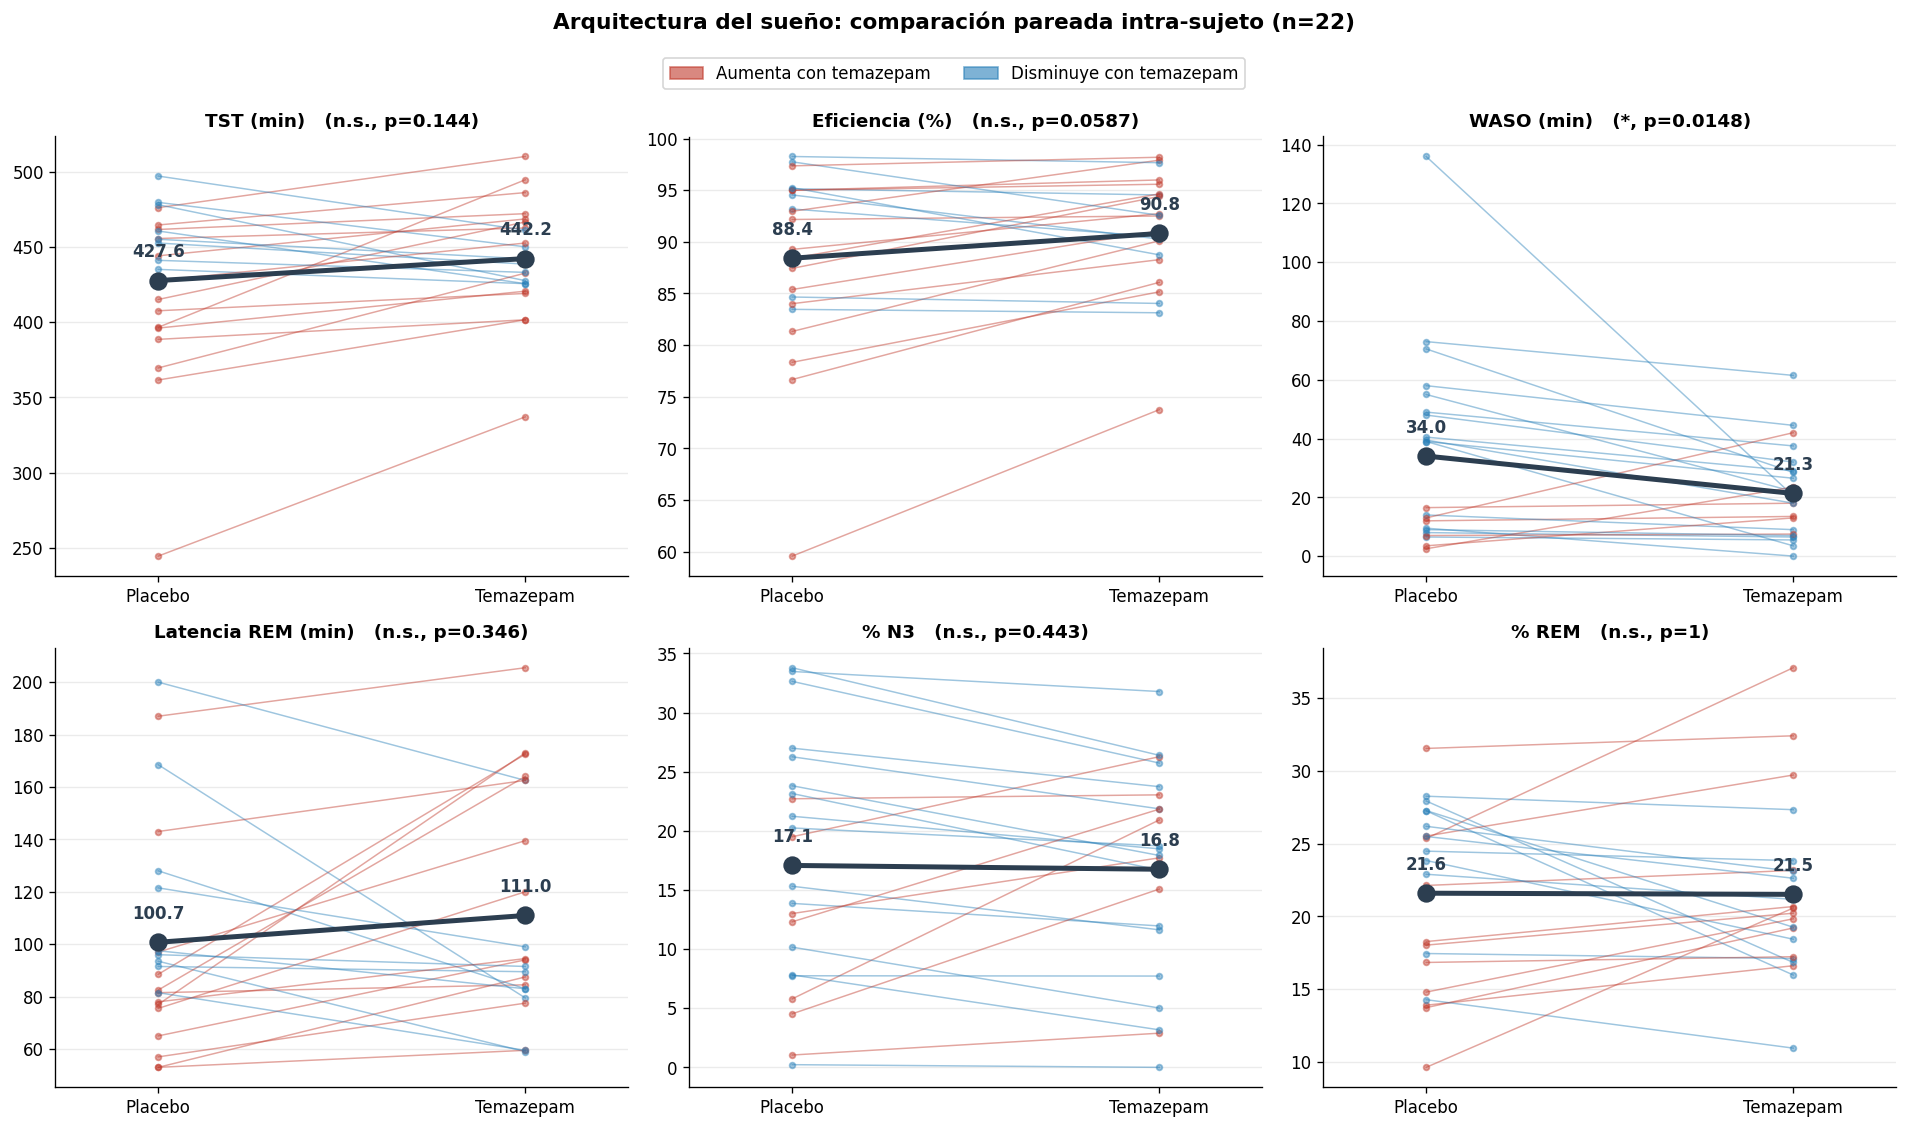

Figura de arquitectura guardada ✓


In [15]:
plot_metrics = ['TST (min)', 'Eficiencia (%)', 'WASO (min)',
                'Latencia REM (min)', '% N3', '% REM']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, m in zip(axes.flatten(), plot_metrics):
    piv = paired[m]
    row = df_test[df_test['Métrica'] == m].iloc[0]

    for subj, r in piv.iterrows():
        rising = r['Temazepam'] > r['Placebo']
        ax.plot([0, 1], [r['Placebo'], r['Temazepam']], '-o', markersize=3.5, linewidth=0.9,
                color='#c0392b' if rising else '#2980b9', alpha=0.45)

    means = [piv['Placebo'].mean(), piv['Temazepam'].mean()]
    ax.plot([0, 1], means, '-o', markersize=10, linewidth=3, color='#2c3e50',
            zorder=5, label='Media')
    for xi, mu in zip([0, 1], means):
        ax.annotate(f'{mu:.1f}', (xi, mu), textcoords='offset points', xytext=(0, 14),
                    ha='center', fontsize=10, fontweight='bold', color='#2c3e50', zorder=6)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Placebo', 'Temazepam'], fontsize=10)
    ax.set_xlim(-0.28, 1.28)
    ax.set_title(f"{m}   ({row['sig.']}, p={row['p (Wilcoxon)']:.3g})",
                 fontsize=11, fontweight='bold')
    ax.grid(axis='y', alpha=0.25)

fig.legend(handles=[
    mpatches.Patch(color='#c0392b', alpha=0.6, label='Aumenta con temazepam'),
    mpatches.Patch(color='#2980b9', alpha=0.6, label='Disminuye con temazepam'),
], loc='upper center', ncol=2, fontsize=10, bbox_to_anchor=(0.5, 1.005))

plt.suptitle('Arquitectura del sueño: comparación pareada intra-sujeto (n=22)',
             fontsize=13, fontweight='bold', y=1.04)
plt.tight_layout()
plt.savefig(IMG / 'arquitectura_placebo_vs_temazepam.png', bbox_inches='tight')
plt.show()
print('Figura de arquitectura guardada ✓')

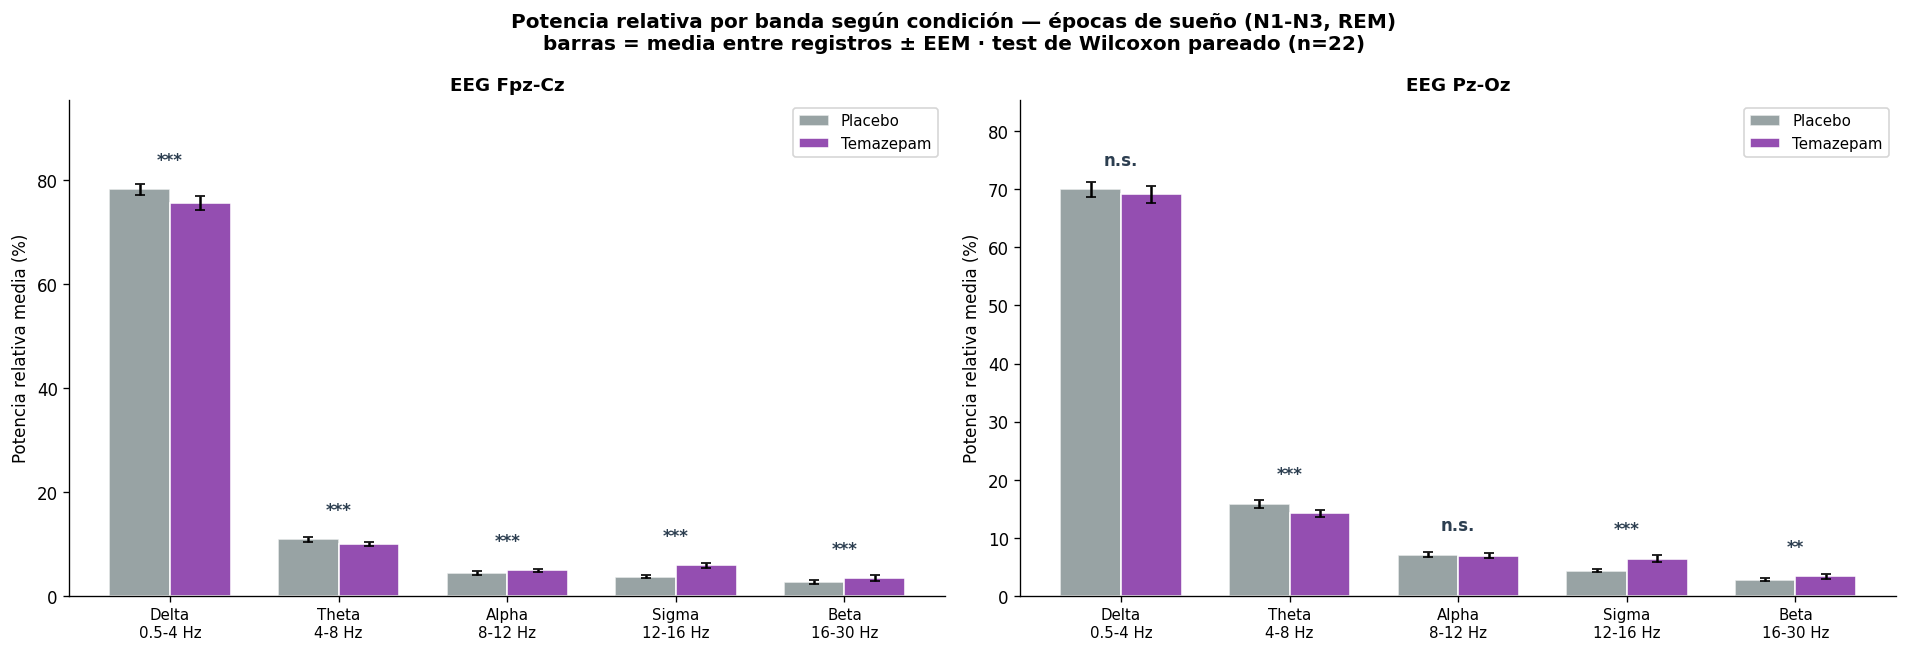

=== Potencia relativa por banda y condición ===

     Canal Banda  Placebo (%)  Temazepam (%)  Δ (T-P)      p  sujetos ↑  n pares
EEG Fpz-Cz Delta        78.26          75.73    -2.53 0.0000          3       22
EEG Fpz-Cz Theta        10.93          10.03    -0.90 0.0001          5       22
EEG Fpz-Cz Alpha         4.42           4.90     0.48 0.0009         17       22
EEG Fpz-Cz Sigma         3.71           5.90     2.19 0.0000         22       22
EEG Fpz-Cz  Beta         2.69           3.44     0.76 0.0001         18       22
 EEG Pz-Oz Delta        69.96          69.09    -0.87 0.2221          9       22
 EEG Pz-Oz Theta        15.86          14.19    -1.67 0.0000          1       22
 EEG Pz-Oz Alpha         7.09           6.92    -0.16 0.3053          8       22
 EEG Pz-Oz Sigma         4.33           6.42     2.09 0.0000         22       22
 EEG Pz-Oz  Beta         2.76           3.38     0.61 0.0022         17       22

— Contraste con lo esperado de una benzodiacepina —
  N3, s

In [16]:
# ── Efecto espectral: potencia relativa por banda y condición ───────────────
band_keys = [b.lower() for b in BANDS]
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

spec_rows = []
for j, ch in enumerate(CHANNELS):
    s = CH_SHORT[ch]
    cols = [f'{s}_rel_{b}' for b in band_keys]

    # Media por registro (sobre épocas de sueño), luego pareo por sujeto
    per_rec = (df_valid[df_valid['label'].isin(SLEEP_STAGES)]
               .groupby('rec', observed=True)[cols].mean()
               .join(df_records.set_index('rec')[['subject', 'condition']]))

    means, errs, pvals = {}, {}, []
    for cond in ['Placebo', 'Temazepam']:
        sub = per_rec[per_rec.condition == cond]
        means[cond] = sub[cols].mean().to_numpy()
        errs[cond] = sub[cols].sem().to_numpy()

    for b, col in zip(band_keys, cols):
        piv = per_rec.pivot_table(index='subject', columns='condition', values=col).dropna()
        _, p = wilcoxon(piv['Placebo'], piv['Temazepam'])
        pvals.append(p)
        spec_rows.append({'Canal': ch, 'Banda': b.capitalize(),
                          'Placebo (%)': piv['Placebo'].mean(),
                          'Temazepam (%)': piv['Temazepam'].mean(),
                          'Δ (T-P)': piv['Temazepam'].mean() - piv['Placebo'].mean(),
                          'p': p,
                          'sujetos ↑': int((piv['Temazepam'] > piv['Placebo']).sum()),
                          'n pares': len(piv)})

    ax = axes[j]
    x, w = np.arange(len(band_keys)), 0.36
    for k, cond in enumerate(['Placebo', 'Temazepam']):
        ax.bar(x + (k - 0.5) * w, means[cond], width=w, yerr=errs[cond], capsize=3,
               label=cond, color=COND_COLORS[cond], edgecolor='white',
               alpha=0.95 if cond == 'Temazepam' else 0.8)

    top = max(means['Placebo'].max(), means['Temazepam'].max())
    for xi, p in zip(x, pvals):
        star = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.'
        h = max(means['Placebo'][xi], means['Temazepam'][xi]) + top * 0.05
        ax.text(xi, h, star, ha='center', va='bottom', fontsize=10,
                fontweight='bold', color='#2c3e50')

    ax.set_xticks(x)
    ax.set_xticklabels([BAND_LABELS[b] for b in BANDS], fontsize=9)
    ax.set_ylim(0, top * 1.22)
    ax.set_ylabel('Potencia relativa media (%)', fontsize=10)
    ax.set_title(f'{ch}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('Potencia relativa por banda según condición — épocas de sueño (N1-N3, REM)\n'
             'barras = media entre registros ± EEM · test de Wilcoxon pareado (n=22)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(IMG / 'bandas_por_condicion.png', bbox_inches='tight')
plt.show()

df_spec = pd.DataFrame(spec_rows)
print('=== Potencia relativa por banda y condición ===\n')
print(df_spec.round({'Placebo (%)': 2, 'Temazepam (%)': 2, 'Δ (T-P)': 2, 'p': 4})
      .to_string(index=False))

# ── Contraste con la predicción farmacológica ──────────────────────────────
def veredicto(delta, p, signo_esperado):
    """Un efecto solo confirma la predicción si es significativo Y va en la dirección correcta."""
    if p >= 0.05:
        return 'sin efecto significativo (p ≥ 0.05)'
    return ('confirma la predicción' if np.sign(delta) == signo_esperado
            else 'CONTRADICE la predicción (dirección opuesta)')


n3 = df_test[df_test['Métrica'] == '% N3'].iloc[0]
print('\n— Contraste con lo esperado de una benzodiacepina —')
print(f"  N3, se esperaba MENOS  : Δ = {n3['Δ (T-P)']:+5.2f} pp  "
      f"p = {n3['p (Wilcoxon)']:.3g}   → {veredicto(n3['Δ (T-P)'], n3['p (Wilcoxon)'], -1)}")
sigma = df_spec[df_spec.Banda == 'Sigma']
for _, r in sigma.iterrows():
    print(f"  Sigma {r['Canal']}, se esperaba MÁS: Δ = {r['Δ (T-P)']:+5.2f} pp  "
          f"p = {r['p']:.3g}   → {veredicto(r['Δ (T-P)'], r['p'], +1)}   "
          f"[sube en {r['sujetos ↑']}/{r['n pares']} sujetos]")

lo, hi = sigma['sujetos ↑'].min(), sigma['sujetos ↑'].max()
cuantos = f'{lo}' if lo == hi else f'{lo}-{hi}'
print(f"\nEl aumento de sigma aparece en los dos canales y en {cuantos} de los "
      f"{sigma['n pares'].iloc[0]} sujetos: es la firma clásica de los husos inducidos por\n"
      "benzodiacepinas. La reducción de N3, en cambio, no alcanza significancia. Es decir, el\n"
      "efecto del fármaco se ve en el espectro antes que en la etiqueta del estadio — relevante\n"
      "para el modelado, porque implica que las features cambian con la condición aunque la\n"
      "distribución de clases apenas lo haga.")

## 13. Resumen y conclusiones del EDA

In [17]:
n_rec, n_subj = df_records.rec.nunique(), df_records.subject.nunique()
horas = len(df_epochs) * EPOCH_SEC / 3600
pct = (counts_valid / counts_valid.sum() * 100)
minority = counts_valid.idxmin()
ir_max = counts_valid.max() / counts_valid.min()

sig_metrics = df_test[df_test['p (Wilcoxon)'] < 0.05]['Métrica'].tolist()
disp = per_rec_pct.std()

print('=' * 72)
print('   RESUMEN EDA — Sleep-EDFx / Sleep Telemetry (dataset completo)')
print('=' * 72)
print(f"""
DATASET
  Registros   : {n_rec} ({n_subj} sujetos × 2 noches)
  Sujetos     : {n_subj} — edad {df_subj.age.min()}-{df_subj.age.max()} años \
(media {df_subj.age.mean():.1f}), {(df_subj.sex == 'F').sum()} F / {(df_subj.sex == 'M').sum()} M
  Fechas      : {df_records.meas_date.min()} a {df_records.meas_date.max()}
  Diseño      : cruzado — cada sujeto con una noche placebo y una con temazepam

SEÑALES
  Canales EEG : {', '.join(CHANNELS)}
  Fs          : {SFREQ:.0f} Hz (idéntica en los {n_rec} registros)
  Época       : {EPOCH_SEC} s = {EPOCH_LEN} muestras

ÉPOCAS
  Totales     : {len(df_epochs):,}  ({horas:.1f} h de registro)
  Válidas     : {len(df_valid):,}  ({len(df_valid) / len(df_epochs) * 100:.1f}%)
  Excluidas   : {(df_epochs['label'] == 'M').sum()} de movimiento (M)
  Por registro: {cov.epocas.min()}-{cov.epocas.max()} (mediana {cov.epocas.median():.0f})

DISTRIBUCIÓN DE CLASES (épocas válidas)
  N2  = {int(counts_valid['N2']):6,d} ({pct['N2']:4.1f}%)  <- CLASE MAYORITARIA
  REM = {int(counts_valid['REM']):6,d} ({pct['REM']:4.1f}%)
  N3  = {int(counts_valid['N3']):6,d} ({pct['N3']:4.1f}%)
  W   = {int(counts_valid['W']):6,d} ({pct['W']:4.1f}%)
  N1  = {int(counts_valid['N1']):6,d} ({pct['N1']:4.1f}%)  <- CLASE MÁS DIFÍCIL

OBSERVACIONES CLAVE
  1. Desbalance severo y estructural: {majority} es {ir_max:.1f}× más frecuente que \
{minority}. Dentro de cada
     registro el desbalance es todavía mayor (IR mediano {ir_per_rec.median():.1f}× \
frente a {ir_max:.1f}× global), así que
     no se corrige acumulando más sujetos: es propio del dominio.
     -> F1-macro y kappa de Cohen como métricas principales, nunca accuracy.
     -> Evaluar class_weight='balanced' en modelos clásicos.

  2. Alta variabilidad entre registros: la desviación estándar entre registros es de \
{disp['N3']:.1f} pp para N3 y {disp['W']:.1f} pp para W. Un modelo validado sobre un
     único sujeto no dice nada sobre cómo generalizará.

  3. Firma espectral consistente con la fisiología: N3 concentra la potencia en delta
     (0.5-4 Hz) y REM presenta un patrón mixto próximo al de vigilia — que es
     precisamente lo que hace difícil separar N1 de REM.

  4. Confusor propio de este subset: la mitad de las noches son bajo temazepam.
     {'Efecto significativo (p<0.05) en: ' + ', '.join(sig_metrics) if sig_metrics else 'Sin efectos significativos detectados'}.
     -> La condición debe registrarse como metadato y considerarse en la estratificación.

  5. Los 44 registros terminan con un bloque de vigilia (mediana \
{np.median(tail_w) * 0.5:.0f} min, máx {tail_w.max() * 0.5:.0f} min; \
{tail_w.sum() / len(df_valid) * 100:.1f}% de las épocas
     válidas), artefacto del protocolo de grabación. Recortarlo llevaría W del \
{pct_w:.1f}% al {pct_w_sc:.1f}%:
     es una decisión de preprocesamiento con efecto medible, a documentar.

RECOMENDACIONES PARA MODELADO
  - Partición SIEMPRE por sujeto (LOSO o k-fold por sujeto). CRÍTICO: las dos noches
    de un mismo sujeto nunca deben caer en splits distintos — hay {n_subj} sujetos,
    no {n_rec} muestras independientes.
  - Métricas: F1-macro, kappa de Cohen, matriz de confusión por clase.
  - Las features espectrales (potencia de banda) discriminan bien N3 y W frente al
    sueño ligero; ya están calculadas en {FEATURES_PARQUET.name}.
  - N1 vs. REM y N1 vs. N2 son las confusiones más probables.
  - Estratificar o al menos reportar por condición (placebo/temazepam) y por edad.
""")
print('=' * 72)

   RESUMEN EDA — Sleep-EDFx / Sleep Telemetry (dataset completo)

DATASET
  Registros   : 44 (22 sujetos × 2 noches)
  Sujetos     : 22 — edad 18-79 años (media 40.2), 15 F / 7 M
  Fechas      : 1994-07-12 a 1994-09-26
  Diseño      : cruzado — cada sujeto con una noche placebo y una con temazepam

SEÑALES
  Canales EEG : EEG Fpz-Cz, EEG Pz-Oz
  Fs          : 100 Hz (idéntica en los 44 registros)
  Época       : 30 s = 3000 muestras

ÉPOCAS
  Totales     : 42,774  (356.4 h de registro)
  Válidas     : 42,691  (99.8%)
  Excluidas   : 83 de movimiento (M)
  Por registro: 821-1131 (mediana 966)

DISTRIBUCIÓN DE CLASES (épocas válidas)
  N2  = 19,851 (46.5%)  <- CLASE MAYORITARIA
  REM =  8,349 (19.6%)
  N3  =  6,415 (15.0%)
  W   =  4,423 (10.4%)
  N1  =  3,653 ( 8.6%)  <- CLASE MÁS DIFÍCIL

OBSERVACIONES CLAVE
  1. Desbalance severo y estructural: N2 es 5.4× más frecuente que N1. Dentro de cada
     registro el desbalance es todavía mayor (IR mediano 8.7× frente a 5.4× global), así que
 

---

### Artefactos generados

| Archivo | Contenido |
|---|---|
| `data/processed/epochs_features.parquet` | Una fila por época: metadatos + features temporales y espectrales por canal |
| `data/processed/psd_record_stage.parquet` | PSD media por registro × estadio × canal × frecuencia |
| `img/*.png` | Las 10 figuras de este notebook |

El caché de `data/processed/` queda dentro del directorio que rastrea DVC, así que tras
la primera ejecución hay que registrarlo:

```bash
dvc add data
git add data.dvc
git commit -m "data: features de epocas para EDA de dataset completo"
dvc push
```